# Quantum teleportation — no-cloning, Bell measurement and classical feed-forward

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 8 — Quantum information protocols*

## 1. Introduction and motivation

You hold a qubit in an unknown state $\vert\psi\rangle$ and you want your colleague, far away, to hold *that* state. Three obvious
ideas fail:

* **Send the qubit.** Often impossible — the qubit may be an atom in a trap, or the channel may destroy photon polarisation.
* **Measure it and send the result.** A single measurement of a qubit yields one bit, not the two real numbers that specify
  $\vert\psi\rangle$, and it destroys the state. Section 8 shows this strategy caps out at an average fidelity of $2/3$.
* **Copy it first, then experiment on the copies.** Forbidden: the **no-cloning theorem** (Section 3).

In 1993 Bennett, Brassard, Crépeau, Jozsa, Peres and Wootters found the way out. If the two parties share one entangled pair
beforehand, then Alice can perform a joint measurement on her unknown qubit *and* her half of the pair, send the two classical bits
she obtains, and Bob can recover the state exactly by applying one of four fixed single-qubit gates. Nothing physical travels except
two classical bits; the state itself is destroyed at Alice's end (as no-cloning demands) and reappears at Bob's. The protocol was
demonstrated with photons in 1997 and has since been run over 1400 km, from the ground to a satellite.

Teleportation is not a curiosity. It is the primitive behind **quantum repeaters** (long-distance entanglement distribution),
**measurement-based quantum computing** (where every gate is a teleportation), **fault-tolerant gate implementations** (magic-state
injection), and it is the operational meaning of "we have distributed entanglement of quality $F$": the fidelity a noisy pair
supports, Eq. (13) below, is a standard figure of merit for quantum-network hardware.

**What we will do.**

1. **No-cloning**, with two independent proofs and a numerical demonstration that the natural "copy" circuit (a CNOT) copies
   classical bits and destroys quantum superpositions (Section 3).
2. **The protocol**, derived by rewriting $\vert\psi\rangle_0\otimes\vert\Phi^+\rangle_{12}$ in the Bell basis of qubits 0 and 1 —
   four lines of algebra that contain the whole idea (Section 4).
3. **The implementation**, with a real mid-circuit measurement and classical feed-forward written so that it stays inside `jit`
   and `vmap`: no Python `if` on a measurement result, only `jnp.where` (Sections 5–6).
4. **Why nothing is transmitted faster than light**: the four outcomes are uniform with probability $1/4$ *whatever* the input, and
   Bob's state before the correction is exactly $\mathbb 1/2$. Without the classical bits the fidelity is exactly $1/2$
   (Section 7).
5. **The classical benchmark $2/3$**, derived from the Haar-averaging identity $\int d\psi\,(\vert\psi\rangle\langle\psi\vert)^{\otimes2}
   =P_{\rm sym}/3$ — the same identity that gives the noisy-teleportation formula (Sections 8–9).
6. **Noisy resources.** A Werner/depolarised Bell pair gives average fidelity $\bar F=(2F_{\rm res}+1)/3$; we verify this on the
   density tensor *and* with quantum trajectories, and find that the protocol beats the classical $2/3$ exactly when the resource
   is entangled (Sections 10–12).
7. **Deferred measurement**: replacing the measurement and the feed-forward by two controlled gates gives literally the same state
   (Section 13).

### What you will learn

*Physics*

* the no-cloning theorem and why linearity alone forbids copying;
* the Bell-basis identity that makes teleportation work, and why exactly 2 classical bits are needed;
* no-signalling as a concrete computation: a maximally mixed conditional state;
* the classical measure-and-prepare limit $2/3$ and the entanglement threshold it implies for a noisy resource.

*Numerical methods*

* exact averages over all input states using a 2-design (six states replace an integral over the Bloch sphere);
* two unravellings of the same noisy protocol — density tensor ($O(4^N)$ memory, exact) and trajectories ($O(2^N)$ memory,
  statistical error $1/\sqrt{M}$) — and the measured agreement between them;
* estimating a fidelity from samples and its shot noise.

*Implementation practice*

* projective measurement with collapse as `apply_gate` with a projector plus a renormalisation;
* classical feed-forward with `jnp.where` on a traced outcome, so the whole protocol is one jitted, vmappable function;
* `vmap` over shots, over input states and over trajectories; explicit PRNG key splitting;
* building $\rho_{\rm in}\otimes\rho_{\rm res}$ and partial traces of a rank-$2N$ density tensor with einsum.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, partial trace, Kraus channels, fidelity;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, collapse, sampling;
* [09 — quantum gates and circuits](../ch04_digital_quantum_circuits/09_quantum_gates_and_circuits.ipynb): CNOT, CZ, rotations;
* [17 — Monte Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb): trajectory unravelling of a channel;
* [19 — Bell states and CHSH](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb): the Bell basis, the Bell-state
  circuit, Werner states and the entanglement threshold $v>1/3$ — all of which reappear here.

**Conventions.** Qubit 0 = Alice's unknown input, qubit 1 = Alice's half of the resource, qubit 2 = Bob's half.
$\vert0\rangle$ is the $+1$ eigenstate of $Z$; qubit $q$ is tensor axis $q$; qubit 0 is the most significant bit of the flat index.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We reuse the gates, the einsum applicators for state vectors and density tensors, reduced density matrices, the state constructors,
the Kraus channels in both their density-matrix and trajectory form, and the fidelity. The measurement with collapse and the whole
protocol are written from scratch below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def rdm_dm(rho, keep):
    """Partial trace of a density TENSOR (rank 2N), keeping the qubits `keep`.

    MATH      rho_A[a,a'] = sum_b rho[a,b ; a',b]
    EINSUM    N=2, keep=(0,):  "abAb->aA"   -- the letter b is REPEATED inside one operand and absent
              from the output: that is a trace over that pair of axes.
    """
    keep = tuple(int(q) for q in keep)
    N = rho.ndim // 2
    ket = list(_LETTERS[:N])
    bra = [(_LETTERS[N + q] if q in keep else ket[q]) for q in range(N)]
    sub = f"{''.join(ket)}{''.join(bra)}->{''.join(ket[q] for q in keep)}{''.join(bra[q] for q in keep)}"
    return jnp.einsum(sub, rho).reshape(2 ** len(keep), 2 ** len(keep))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def _sqrtm_psd(A):
    """Square root of a positive semi-definite matrix via eigendecomposition: V sqrt(w) V^dag."""
    w, v = jnp.linalg.eigh(A)
    return (v * jnp.sqrt(jnp.clip(w, 0, None))) @ v.conj().T

def fidelity_dm(rho, sigma):
    """Uhlmann fidelity F(rho,sigma) = (Tr sqrt( sqrt(rho) sigma sqrt(rho) ))^2 for dense matrices."""
    s = _sqrtm_psd(rho)
    w = jnp.linalg.eigvalsh(s @ sigma @ s)
    return jnp.sum(jnp.sqrt(jnp.clip(w, 0, None))) ** 2

def partial_transpose(rho, qubits):
    """Partial transpose on subsystem A = `qubits` of a density TENSOR.
    In tensor form it is trivial: SWAP the ket axis q with the bra axis N+q for q in A.
    (With a 2^N x 2^N matrix this requires painful index gymnastics -- here: one `transpose`.)"""
    N = rho.ndim // 2
    perm = list(range(2 * N))
    for q in qubits:
        perm[q], perm[N + q] = perm[N + q], perm[q]
    return jnp.transpose(rho, perm)

def negativity(rho, qubits):
    """Entanglement negativity (Peres-Horodecki / PPT criterion).
        N(rho) = (||rho^{T_A}||_1 - 1)/2 = sum of |negative eigenvalues| of the partial transpose,
        E_N    = log2 ||rho^{T_A}||_1 = log2(2N+1)      (logarithmic negativity).
    N > 0  =>  entangled (for 2x2 and 2x3 systems also <=).   Returns (N, E_N)."""
    lam = jnp.linalg.eigvalsh(dm_matrix(partial_transpose(rho, qubits)))
    neg = jnp.sum(jnp.abs(lam) - lam) / 2
    return neg, jnp.log2(2 * neg + 1)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def qubit_state(theta, phi=0.0):
    """One qubit on the Bloch sphere:  |psi> = cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>.
    theta = polar angle from the north pole (|0>), phi = azimuth.  theta, phi may be traced."""
    return jnp.array([jnp.cos(theta / 2) + 0j, jnp.exp(1j * phi) * jnp.sin(theta / 2)], dtype=CDTYPE)


def fid_state_dm(ket, rho_mat):
    """Fidelity of a MIXED state with a PURE target:  F = <psi| rho |psi>  (a linear functional of rho)."""
    return jnp.real(jnp.vdot(ket, rho_mat @ ket))


# The test inputs used throughout: name -> (theta, phi)
TEST_INPUTS = {"|0>": (0.0, 0.0), "|1>": (np.pi, 0.0), "|+>": (np.pi / 2, 0.0),
               "Ry(pi/4)|0>": (np.pi / 4, 0.0), "Ry(3pi/4)|0>": (3 * np.pi / 4, 0.0),
               "generic (th=pi/3, ph=0.7)": (np.pi / 3, 0.7)}

## 3. The no-cloning theorem

### 3.1 Statement

**Theorem (Wootters and Zurek 1982; Dieks 1982).** There is no unitary $U$ acting on two qubits and no fixed "blank" state
$\vert b\rangle$ such that

$$U\left(\vert\psi\rangle\otimes\vert b\rangle\right)=\vert\psi\rangle\otimes\vert\psi\rangle\qquad\text{for every }\vert\psi\rangle .$$

### 3.2 Proof 1: linearity

Suppose such a $U$ existed. Apply it to the two basis states:

$$U\left(\vert0\rangle\vert b\rangle\right)=\vert00\rangle,\qquad U\left(\vert1\rangle\vert b\rangle\right)=\vert11\rangle .$$

Now feed it the superposition $\vert\psi\rangle=\alpha\vert0\rangle+\beta\vert1\rangle$. Because $U$ is **linear**,

$$U\left(\vert\psi\rangle\vert b\rangle\right)=\alpha\,U\left(\vert0\rangle\vert b\rangle\right)+\beta\,U\left(\vert1\rangle\vert b\rangle\right)
  =\alpha\vert00\rangle+\beta\vert11\rangle .$$

But cloning demands

$$\vert\psi\rangle\vert\psi\rangle=\alpha^2\vert00\rangle+\alpha\beta\vert01\rangle+\beta\alpha\vert10\rangle+\beta^2\vert11\rangle .$$

Comparing coefficients term by term gives $\alpha^2=\alpha$, $\beta^2=\beta$ and $\alpha\beta=0$, so $\{\alpha,\beta\}=\{1,0\}$:
the two sides agree only for the basis states themselves. **Linearity, and nothing else, is the obstruction** — the argument never
used unitarity, so it rules out any linear machine, not just a unitary one.

### 3.3 Proof 2: inner products

A second argument, which also tells us *which* states can be copied. Unitaries preserve inner products. If $U$ clones both
$\vert\psi\rangle$ and $\vert\varphi\rangle$ then

$$\langle\psi\vert\varphi\rangle=\langle\psi\vert\varphi\rangle\,\langle b\vert b\rangle
  =\left(\langle\psi\vert\otimes\langle b\vert\right)U^{\dagger}U\left(\vert\varphi\rangle\otimes\vert b\rangle\right)
  =\langle\psi\vert\varphi\rangle^{2} .$$

Writing $x=\langle\psi\vert\varphi\rangle$ we need $x=x^2$, hence $x=0$ or $x=1$: a cloning machine can copy a set of states only if
they are **mutually orthogonal** (classical information) or identical. $\square$

Neither proof is weakened by giving the machine a **work space**. A cloner with an ancilla would act as
$U\left(\vert\psi\rangle\vert b\rangle\vert A\rangle\right)=\vert\psi\rangle\vert\psi\rangle\vert A_\psi\rangle$, and the same
manipulation gives $x=x^2\langle A_\psi\vert A_\varphi\rangle$, hence $\vert x\vert\le\vert x\vert^2$, hence $x=0$ or
$\vert x\vert=1$ — the same conclusion. Extra degrees of freedom do not help.

### 3.4 What the "copy" circuit actually does

The natural candidate for a copier is CNOT: it maps $\vert0\rangle\vert0\rangle\to\vert00\rangle$ and
$\vert1\rangle\vert0\rangle\to\vert11\rangle$, so it *does* copy classical bits. On a superposition it produces, as the proof says,
$\alpha\vert00\rangle+\beta\vert11\rangle$ — an **entangled** state, not two copies. With $\alpha=\cos\frac\theta2$,
$\beta=\sin\frac\theta2$ the overlap with the desired $\vert\psi\rangle\vert\psi\rangle$ is
$\alpha^3+\beta^3$, so the joint fidelity is

$$F_{\rm joint}(\theta)=\left(\cos^3\tfrac{\theta}{2}+\sin^3\tfrac{\theta}{2}\right)^2 ,$$

while each individual output qubit is left in the *mixed* state $\mathrm{diag}(\alpha^2,\beta^2)$, whose fidelity with
$\vert\psi\rangle$ is $\alpha^4+\beta^4$. Both equal 1 at $\theta=0,\pi$ (classical inputs) and drop to $1/2$ at $\theta=\pi/2$
(the equator), where the "copy" is worthless. Averaged over the Bloch sphere the single-copy fidelity is
$\langle\alpha^4+\beta^4\rangle=\langle1-\tfrac12\sin^2\theta\rangle=2/3$ (Section 8 derives $\langle\sin^2\theta\rangle=2/3$);
the code below computes that average from the curve.

For comparison, the optimal *approximate* universal $1\to2$ cloner — the machine constructed by Bužek and Hillery (1996) and
proved optimal a few years later — delivers a single-copy fidelity of exactly $5/6\approx0.833$ for **every** input. It is worse
than CNOT near the poles and much better at the equator, and its average $5/6$ beats CNOT's $2/3$; it is still strictly below 1, as
it must be.

In [4]:
# ==============================================================================
# STEP 1: the no-cloning theorem, illustrated with the CNOT "copier"
# ==============================================================================
def cnot_copier(ket):
    """Try to copy `ket` onto a blank |0>:  |psi>|0>  ->  CNOT |psi>|0>.   Returns the 2-qubit output tensor."""
    psi = jnp.einsum("a,b->ab", ket, jnp.array([1.0, 0.0], dtype=CDTYPE))
    return apply_gate(psi, CNOT, [0, 1])


theta_grid = np.linspace(0.0, np.pi, 181)
F_joint, F_single = [], []
for th in theta_grid:
    ket = qubit_state(float(th))
    out = cnot_copier(ket)
    target = jnp.einsum("a,b->ab", ket, ket)                       # the state a perfect cloner would produce
    F_joint.append(float(jnp.abs(jnp.vdot(target, out)) ** 2))
    F_single.append(float(fid_state_dm(ket, rdm(out, [0]))))       # fidelity of ONE output copy
F_joint, F_single = np.array(F_joint), np.array(F_single)

# Bloch-sphere (Haar) average of a function of theta alone:  <f> = (1/2) int_0^pi f(theta) sin(theta) dtheta.
# Trapezoidal rule on the 181-point grid; the weight sin(theta) is the solid-angle measure.
_w = np.sin(theta_grid)
_dth = np.diff(theta_grid)


def bloch_average(f):
    """Average of f(theta) over the Bloch sphere, by trapezoidal integration of f sin(theta)/2."""
    g = np.asarray(f) * _w
    return float(0.5 * np.sum(0.5 * (g[:-1] + g[1:]) * _dth))


print(f"{'input':28s} {'F(joint, 2 copies)':>19s} {'F(one copy)':>12s} {'purity of one copy':>19s}")
for name, (th, ph) in TEST_INPUTS.items():
    ket = qubit_state(th, ph)
    out = cnot_copier(ket)
    r0 = rdm(out, [0])
    tgt = jnp.einsum("a,b->ab", ket, ket)
    print(f"{name:28s} {float(jnp.abs(jnp.vdot(tgt, out)) ** 2):19.6f} "
          f"{float(fid_state_dm(ket, r0)):12.6f} {float(purity(r0)):19.6f}")

# --- CHECKPOINT: the inner-product identity of Proof 2, verified on the CNOT map -----------------------
kets = [qubit_state(th, ph) for th, ph in TEST_INPUTS.values()]
print("\nCHECKPOINT  <psi|phi> vs <output_psi|output_phi> for the CNOT map "
      "(a cloner would square the overlap):")
print(f"{'pair':>9s} {'<psi|phi>':>11s} {'<out|out>':>11s} {'<psi|phi>^2':>12s}")
for i, j in [(0, 2), (2, 3), (3, 5)]:
    ov = complex(jnp.vdot(kets[i], kets[j]))
    ov_out = complex(jnp.vdot(cnot_copier(kets[i]).reshape(-1), cnot_copier(kets[j]).reshape(-1)))
    print(f"{i}<->{j:<5d} {abs(ov):11.6f} {abs(ov_out):11.6f} {abs(ov) ** 2:12.6f}")
    assert abs(abs(ov_out) - abs(ov)) < 1e3 * TOL       # unitary: overlaps are PRESERVED, not squared

print(f"\nBloch-sphere average of the CNOT single-copy fidelity = {bloch_average(F_single):.5f}  "
      f"(exact value 2/3 = {2 / 3:.5f}; the optimal universal cloner gives 5/6 = {5 / 6:.5f} for every input)")
assert abs(bloch_average(F_single) - 2 / 3) < 1e-4     # trapezoidal quadrature error on a 181-point grid

input                         F(joint, 2 copies)  F(one copy)  purity of one copy
|0>                                     1.000000     1.000000            1.000000
|1>                                     1.000000     1.000000            1.000000
|+>                                     0.500000     0.500000            0.500000
Ry(pi/4)|0>                             0.713388     0.750000            0.750000
Ry(3pi/4)|0>                            0.713388     0.750000            0.750000
generic (th=pi/3, ph=0.7)               0.561695     0.625000            0.625000

CHECKPOINT  <psi|phi> vs <output_psi|output_phi> for the CNOT map (a cloner would square the overlap):
     pair   <psi|phi>   <out|out>  <psi|phi>^2
0<->2        0.707107    0.707107     0.500000
2<->3        0.923880    0.923880     0.853553
3<->5        0.954443    0.954443     0.910961

Bloch-sphere average of the CNOT single-copy fidelity = 0.66664  (exact value 2/3 = 0.66667; the optimal universal cloner gives 5/6 =

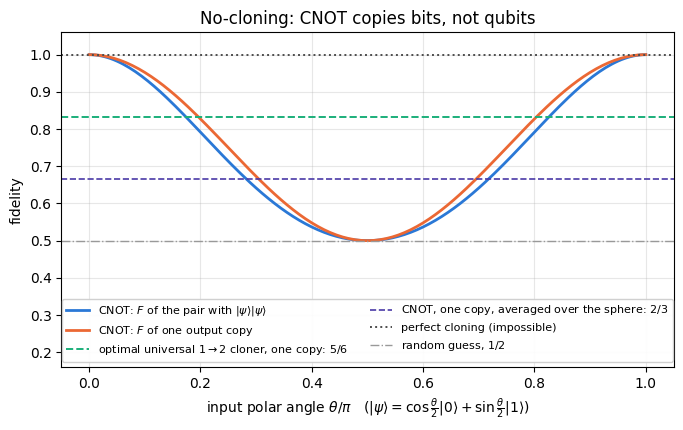

In [5]:
# ==============================================================================
# FIGURE: what the CNOT "copier" really does
# ==============================================================================
fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.plot(theta_grid / np.pi, F_joint, "-", color=PALETTE[0], lw=2,
        label=r"CNOT: $F$ of the pair with $|\psi\rangle|\psi\rangle$")
ax.plot(theta_grid / np.pi, F_single, "-", color=PALETTE[1], lw=2, label=r"CNOT: $F$ of one output copy")
ax.axhline(5 / 6, color=PALETTE[2], ls="--", lw=1.4,
           label=r"optimal universal $1\to2$ cloner, one copy: $5/6$")
ax.axhline(2 / 3, color=PALETTE[5], ls="--", lw=1.2,
           label=r"CNOT, one copy, averaged over the sphere: $2/3$")
ax.axhline(1.0, color="0.3", ls=":", lw=1.4, label="perfect cloning (impossible)")
ax.axhline(0.5, color="0.6", ls="-.", lw=1.0, label="random guess, $1/2$")
ax.set_xlabel(r"input polar angle $\theta/\pi$   ($|\psi\rangle=\cos\frac{\theta}{2}|0\rangle+\sin\frac{\theta}{2}|1\rangle$)")
ax.set_ylabel("fidelity")
ax.set_ylim(0.16, 1.06)
ax.set_title("No-cloning: CNOT copies bits, not qubits")
ax.legend(fontsize=8, loc="lower center", ncol=2, frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()

At the poles $\theta=0,\pi$ the input is a classical bit and the CNOT copies it perfectly — both fidelities are 1 and the output
copy is pure. Everywhere else the fidelity falls, reaching $1/2$ at the equator ($\vert+\rangle$), where the "copy" carries no more
information about $\vert\psi\rangle$ than a coin toss and the output qubit has purity $1/2$: it is maximally mixed. Averaged over
the sphere the single-copy fidelity is $0.66664$ — the value $2/3$, up to the $3\cdot10^{-5}$ error of the trapezoidal rule on the
$181$-point $\theta$ grid. The checkpoint shows why the CNOT cannot do better: being unitary it
*preserves* overlaps, whereas cloning would have to *square* them. The upper dashed line marks the best any machine can do for all
inputs at once.

## 4. The protocol and its algebra

### 4.1 Setup

* Qubit 0: Alice's unknown input $\vert\psi\rangle=\alpha\vert0\rangle+\beta\vert1\rangle$.
* Qubits 1 and 2: a shared Bell pair $\vert\Phi^+\rangle_{12}=\tfrac{1}{\sqrt2}(\vert00\rangle+\vert11\rangle)$, qubit 1 with
  Alice, qubit 2 with Bob. Distributing this pair is the only thing that must happen "before"; it does not depend on $\vert\psi\rangle$.

The total state is

$$\vert\Psi\rangle=\vert\psi\rangle_0\otimes\vert\Phi^+\rangle_{12}
  =\frac{1}{\sqrt2}\Big(\alpha\vert000\rangle+\alpha\vert011\rangle+\beta\vert100\rangle+\beta\vert111\rangle\Big). \tag{1}$$

### 4.2 Rewriting in the Bell basis of qubits 0 and 1

Alice will measure qubits 0 and 1 *jointly*, in the Bell basis. So express the first two kets of every term in that basis. Inverting
the definitions of the Bell states (Section 3 of the
[CHSH notebook](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb)):

$$\begin{aligned}
\vert00\rangle&=\tfrac{1}{\sqrt2}\left(\vert\Phi^+\rangle+\vert\Phi^-\rangle\right), &
\vert01\rangle&=\tfrac{1}{\sqrt2}\left(\vert\Psi^+\rangle+\vert\Psi^-\rangle\right), \\
\vert10\rangle&=\tfrac{1}{\sqrt2}\left(\vert\Psi^+\rangle-\vert\Psi^-\rangle\right), &
\vert11\rangle&=\tfrac{1}{\sqrt2}\left(\vert\Phi^+\rangle-\vert\Phi^-\rangle\right).
\end{aligned}$$

Substitute into Eq. (1), keeping track of which ket belongs to qubit 2 (written last):

$$\begin{aligned}
\vert\Psi\rangle&=\tfrac{1}{\sqrt2}\Big[\alpha\,\vert00\rangle_{01}\vert0\rangle_2+\alpha\,\vert01\rangle_{01}\vert1\rangle_2
                 +\beta\,\vert10\rangle_{01}\vert0\rangle_2+\beta\,\vert11\rangle_{01}\vert1\rangle_2\Big]\\[2pt]
&=\tfrac12\Big[\alpha\left(\vert\Phi^+\rangle+\vert\Phi^-\rangle\right)\vert0\rangle
              +\alpha\left(\vert\Psi^+\rangle+\vert\Psi^-\rangle\right)\vert1\rangle\\
&\qquad+\beta\left(\vert\Psi^+\rangle-\vert\Psi^-\rangle\right)\vert0\rangle
       +\beta\left(\vert\Phi^+\rangle-\vert\Phi^-\rangle\right)\vert1\rangle\Big].
\end{aligned}$$

Now collect the four Bell states:

$$\boxed{\;\vert\Psi\rangle=\frac12\Big[\vert\Phi^+\rangle_{01}\big(\alpha\vert0\rangle+\beta\vert1\rangle\big)
+\vert\Phi^-\rangle_{01}\big(\alpha\vert0\rangle-\beta\vert1\rangle\big)
+\vert\Psi^+\rangle_{01}\big(\alpha\vert1\rangle+\beta\vert0\rangle\big)
+\vert\Psi^-\rangle_{01}\big(\alpha\vert1\rangle-\beta\vert0\rangle\big)\Big]\;} \tag{2}$$

Read off what sits on qubit 2 in each term, using $Z\vert\psi\rangle=\alpha\vert0\rangle-\beta\vert1\rangle$,
$X\vert\psi\rangle=\alpha\vert1\rangle+\beta\vert0\rangle$ and $XZ\vert\psi\rangle=\alpha\vert1\rangle-\beta\vert0\rangle$:

| Alice's Bell outcome | bits $(m_1,m_2)$ | Bob's qubit is | Bob must apply |
|---|---|---|---|
| $\vert\Phi^+\rangle$ | $(0,0)$ | $\vert\psi\rangle$ | nothing |
| $\vert\Phi^-\rangle$ | $(1,0)$ | $Z\vert\psi\rangle$ | $Z$ |
| $\vert\Psi^+\rangle$ | $(0,1)$ | $X\vert\psi\rangle$ | $X$ |
| $\vert\Psi^-\rangle$ | $(1,1)$ | $XZ\vert\psi\rangle$ | $X$ first, then $Z$ |

Compactly, with $m_1,m_2\in\{0,1\}$ labelling the Bell states as in the second column
($B_{00}=\Phi^+$, $B_{01}=\Psi^+$, $B_{10}=\Phi^-$, $B_{11}=\Psi^-$ — the labelling the circuit below produces),

$$\vert\Psi\rangle=\frac12\sum_{m_1,m_2}\vert B_{m_1m_2}\rangle_{01}\otimes X^{m_2}Z^{m_1}\vert\psi\rangle_2 . \tag{3}$$

**Three observations, and they are the whole protocol.**

1. Equation (3) is an *identity*, true before anything happens. Nothing has moved yet.
2. Every term has the same prefactor $1/2$, so **each Bell outcome has probability $\vert1/2\vert^2=1/4$, independently of
   $\alpha$ and $\beta$**. Alice's measurement record contains *no information* about $\vert\psi\rangle$ — which is exactly why it
   can be broadcast publicly, and why no signal is sent (Section 7).
3. Conditioned on outcome $(m_1,m_2)$, Bob's qubit is in the pure state $X^{m_2}Z^{m_1}\vert\psi\rangle$. Since $X^2=Z^2=\mathbb 1$,
   applying first $X^{m_2}$ and then $Z^{m_1}$ undoes it:
   $Z^{m_1}X^{m_2}\,X^{m_2}Z^{m_1}\vert\psi\rangle=\vert\psi\rangle$. Two classical bits select one of four fixed gates.
   The opposite order costs only a sign, $X^{m_2}Z^{m_1}=(-1)^{m_1m_2}Z^{m_1}X^{m_2}$; in *this* protocol that sign is a global
   phase of Bob's state in a branch that has already been singled out by the measurement, so it is unobservable. It stops being
   unobservable in the coherent version of Section 13, where the four branches are still superposed — so we keep the order fixed.

### 4.3 The circuit

Alice cannot "measure in the Bell basis" directly; her detectors read the computational basis. But Section 3 of the CHSH notebook
showed that $H_0$ followed by $\text{CNOT}_{0\to1}$ maps the *computational* basis onto the Bell basis. The **inverse** of that
circuit is the same two gates in the opposite order, $\text{CNOT}_{0\to1}$ first and $H_0$ second (both gates are self-inverse, so
$\left(\text{CNOT}_{0\to1}H_0\right)^{-1}=H_0\,\text{CNOT}_{0\to1}$), and it maps the Bell basis onto the computational basis:

$$\vert\Phi^+\rangle\to\vert00\rangle,\quad\vert\Psi^+\rangle\to\vert01\rangle,\quad
  \vert\Phi^-\rangle\to\vert10\rangle,\quad\vert\Psi^-\rangle\to\vert11\rangle .$$

So the full protocol is:

```
 q0 : |psi>  ------------•---- H ---- [measure] === m1 ===+
                         |                                |
 q1 : ---|Phi+>--------- X ---------- [measure] === m2 ==+|
            |                                            ||
 q2 : ------+-------------------------------------------[X^m2]--[Z^m1]---> |psi>
```

with $m_1$ the result on qubit 0 and $m_2$ the result on qubit 1. The double lines are *classical* wires: the two bits must be
physically transmitted, at or below the speed of light, before Bob can finish. That is the whole reason teleportation does not
violate relativity.

## 5. From formula to code: measurement with collapse

Before the protocol we need one new primitive: a **projective measurement of one qubit with collapse**, written so that it survives
`jit` and `vmap`. The recipe from [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb) is

$$p(0)=\langle\psi\vert\Pi_0^{(q)}\vert\psi\rangle=\left[\rho_q\right]_{00},\qquad
  \vert\psi\rangle\;\to\;\frac{\Pi_m^{(q)}\vert\psi\rangle}{\sqrt{p(m)}} ,$$

where $\Pi_0=\vert0\rangle\langle0\vert$, $\Pi_1=\vert1\rangle\langle1\vert$. Two implementation points matter:

* the probability comes from the **one-qubit reduced density matrix** — one einsum, no $2^N$ scan;
* the outcome is a *traced* random number, so we may not write `if m == 1: ...`. Instead `jnp.where(m == 0, P0, P1)` selects the
  projector and `jnp.where(m == 1, X, I2)` selects the correction. Both are ordinary array operations, so the whole protocol
  compiles into one XLA program and `vmap` gives us thousands of independent runs for free.

> **JAX practice.** This is the general pattern for *mid-circuit measurement and classical feed-forward*: replace control flow by
> data flow. A Python `if` would force the value of a traced array and raise `ConcretizationTypeError`; `jnp.where` evaluates both
> branches (cheap here: two $2\times2$ matrices) and picks one. For expensive branches use `lax.cond` instead, which really does
> execute only one side — but `lax.cond` under `vmap` converts itself back into a `where`, so for small gates `where` is both
> simpler and faster.

In [6]:
# ==============================================================================
# STEP 2: projective measurement with collapse, and the teleportation circuit
# ==============================================================================
def measure_z(key, psi, q):
    """Measure qubit `q` in the Z basis. Returns (outcome m in {0,1}, collapsed and renormalised state).

    MATH   p(0) = [rho_q]_{00} (Born rule from the 1-qubit reduced density matrix);
           collapse |psi> -> Pi_m |psi> / sqrt(p(m)).
    JAX    `m` is a traced integer -> the projector is selected with `jnp.where`, never a Python `if`,
           so this function is jit- and vmap-compatible (vmap over keys = many independent runs).
    """
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    m = (jax.random.uniform(key) >= p0).astype(jnp.int32)          # 0 with probability p0
    psi = apply_gate(psi, jnp.where(m == 0, P0, P1), [q])
    return m, psi / jnp.linalg.norm(psi)


def three_qubit_input(ket, resource=None):
    """|psi>_0 (x) |Phi+>_{12} as a rank-3 tensor.   EINSUM: "a,bc->abc" -- an outer product, nothing summed."""
    res = bell_state("phi+") if resource is None else resource
    return jnp.einsum("a,bc->abc", ket, res)


def alice_bell_measurement_gates(psi):
    """Rotate the Bell basis of qubits (0,1) onto the computational basis:  H_0 . CNOT_{0->1}."""
    psi = apply_gate(psi, CNOT, [0, 1])
    return apply_gate(psi, H, [0])


@jax.jit
def teleport(key, ket, apply_corr=1):
    """ONE run of the teleportation protocol on a pure input `ket`.

    Returns (m1, m2, psi_final).  `apply_corr` is 1 (normal protocol) or 0 (Bob does nothing) -- it is a
    traced integer, so both variants share one compiled program.
    STEPS  1. |psi>_0 (x) |Phi+>_{12}
           2. Alice: CNOT(0->1), H(0)            [rotate her Bell basis onto the computational basis]
           3. Alice: measure qubits 0 and 1       [mid-circuit measurement, with collapse]
           4. Bob:   X^{m2} then Z^{m1} on qubit 2  [classical feed-forward via jnp.where]
    """
    psi = three_qubit_input(ket)
    psi = alice_bell_measurement_gates(psi)
    k1, k2 = jax.random.split(key)
    m1, psi = measure_z(k1, psi, 0)
    m2, psi = measure_z(k2, psi, 1)
    c1, c2 = m1 * apply_corr, m2 * apply_corr
    psi = apply_gate(psi, jnp.where(c2 == 1, X, I2), [2])          # X correction first ...
    psi = apply_gate(psi, jnp.where(c1 == 1, Z, I2), [2])          # ... then Z
    return m1, m2, psi


# --- gate-by-gate walk for the input |+> ----------------------------------------------------------------
print("GATE-BY-GATE TELEPORTATION OF |+>\n")
ket_plus = qubit_state(np.pi / 2)
psi = three_qubit_input(ket_plus)
print(f"  step 1  |psi>_0 (x) |Phi+>_12 :  amplitudes = {np.round(np.asarray(psi).reshape(-1), 4)}")
print(f"          <Z_1 Z_2> of the resource = {float(jnp.real(jnp.vdot(psi, apply_gate(apply_gate(psi, Z, [1]), Z, [2])))):+.4f}"
      f"   (perfectly correlated)")
psi = apply_gate(psi, CNOT, [0, 1])
print(f"  step 2a CNOT(0 -> 1)          :  amplitudes = {np.round(np.asarray(psi).reshape(-1), 4)}")
psi = apply_gate(psi, H, [0])
print(f"  step 2b H(0)                  :  amplitudes = {np.round(np.asarray(psi).reshape(-1), 4)}")
print("          (all eight amplitudes have modulus 1/(2 sqrt(2)): every outcome (m1,m2) has probability 1/4)")
print(f"  Bob's state before the measurement, rho_2 =\n{np.round(np.asarray(rdm(psi, [2])), 4)}")
print("          -> exactly the maximally mixed state: no information has reached Bob yet.")

m1, m2, psi_out = teleport(jax.random.PRNGKey(0), ket_plus)
print(f"\n  step 3  measured (m1, m2) = ({int(m1)}, {int(m2)})")
print(f"  step 4  Bob applies X^{int(m2)} then Z^{int(m1)}")
print(f"          Bob's final state rho_2 =\n{np.round(np.asarray(rdm(psi_out, [2])), 4)}")
print(f"          fidelity with the input |+> : {float(fid_state_dm(ket_plus, rdm(psi_out, [2]))):.12f}")

GATE-BY-GATE TELEPORTATION OF |+>

  step 1  |psi>_0 (x) |Phi+>_12 :  amplitudes = [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j 0. +0.j 0.5+0.j]
          <Z_1 Z_2> of the resource = +1.0000   (perfectly correlated)
  step 2a CNOT(0 -> 1)          :  amplitudes = [0.5+0.j 0. +0.j 0. +0.j 0.5+0.j 0. +0.j 0.5+0.j 0.5+0.j 0. +0.j]
  step 2b H(0)                  :  amplitudes = [ 0.3536+0.j  0.3536+0.j  0.3536+0.j  0.3536+0.j  0.3536+0.j -0.3536+0.j
 -0.3536+0.j  0.3536+0.j]
          (all eight amplitudes have modulus 1/(2 sqrt(2)): every outcome (m1,m2) has probability 1/4)


  Bob's state before the measurement, rho_2 =
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]
          -> exactly the maximally mixed state: no information has reached Bob yet.



  step 3  measured (m1, m2) = (1, 0)
  step 4  Bob applies X^0 then Z^1
          Bob's final state rho_2 =
[[0.5+0.j 0.5+0.j]
 [0.5+0.j 0.5+0.j]]
          fidelity with the input |+> : 1.000000000000


The printed amplitudes after step 2b all have the same modulus, which is Eq. (3) in numbers: the four Alice outcomes are
equiprobable. Bob's reduced density matrix before the measurement is exactly $\mathbb 1/2$ — he holds no information at all — and
after the two classical bits arrive and the correction is applied, his qubit is $\vert+\rangle$ with fidelity 1 to machine
precision. The state has moved from qubit 0 to qubit 2; and qubit 0 has been destroyed by the measurement, as no-cloning requires.

## 6. Does it work for every input? Fidelity over many runs

One run proves nothing: the measurement is random, so we must check *all four* branches, for several inputs. We `vmap` the whole
protocol over PRNG keys — one key per run, exactly as one experiment per key — and collect the fidelity and the outcome.

In [7]:
# ==============================================================================
# STEP 3: teleportation fidelity for a zoo of inputs (vmap over shots)
# ==============================================================================
# PARAMETERS ---------------------------------------------------------------------------------------
N_SHOTS = 2000                       # independent runs of the protocol per input state
# --------------------------------------------------------------------------------------------------


@partial(jax.jit, static_argnums=(2,))
def teleport_batch(key, ket, shots, apply_corr=1):
    """`shots` independent runs: vmap of `teleport` over keys.  Returns (fidelities, m1, m2)."""
    keys = jax.random.split(key, shots)

    def one(k):
        m1, m2, psi = teleport(k, ket, apply_corr)
        return fid_state_dm(ket, rdm(psi, [2])), m1, m2

    return jax.vmap(one)(keys)


print(f"{N_SHOTS} runs per input state\n")
print(f"{'input':28s} | {'F (with corrections)':>21s} | {'F (no corrections)':>19s} | "
      f"{'p(00) p(01) p(10) p(11)':>26s}")
for i, (name, (th, ph)) in enumerate(TEST_INPUTS.items()):
    ket = qubit_state(th, ph)
    F_c, m1, m2 = teleport_batch(jax.random.PRNGKey(10 + i), ket, N_SHOTS, 1)
    F_n, _, _ = teleport_batch(jax.random.PRNGKey(10 + i), ket, N_SHOTS, 0)
    counts = np.array([float(jnp.mean((m1 == a) & (m2 == b))) for a in (0, 1) for b in (0, 1)])
    print(f"{name:28s} | {float(jnp.mean(F_c)):11.10f} +-{float(jnp.std(F_c)):7.1e} | "
          f"{float(jnp.mean(F_n)):19.6f} | " + " ".join(f"{c:5.3f}" for c in counts))
    assert float(jnp.min(F_c)) > 1 - 1e3 * TOL              # EVERY run must be perfect, not just the average

print("\nCHECKPOINT  every single run reached fidelity 1 (to machine precision) for every input state.")

2000 runs per input state

input                        |  F (with corrections) |  F (no corrections) |    p(00) p(01) p(10) p(11)


|0>                          | 1.0000000000 +-0.0e+00 |            0.500500 | 0.243 0.242 0.258 0.258
|1>                          | 1.0000000000 +-0.0e+00 |            0.490000 | 0.258 0.252 0.233 0.259
|+>                          | 1.0000000000 +-0.0e+00 |            0.495500 | 0.251 0.245 0.250 0.255
Ry(pi/4)|0>                  | 1.0000000000 +-0.0e+00 |            0.493750 | 0.247 0.244 0.251 0.259
Ry(3pi/4)|0>                 | 1.0000000000 +-0.0e+00 |            0.494750 | 0.250 0.236 0.254 0.261
generic (th=pi/3, ph=0.7)    | 1.0000000000 +-0.0e+00 |            0.493701 | 0.238 0.264 0.246 0.252

CHECKPOINT  every single run reached fidelity 1 (to machine precision) for every input state.


The fidelity with corrections is $1$ in **every single run** — not on average, exactly, in each of the four branches, for every
input including the complex-amplitude one. Without the corrections it collapses to $1/2$ for every input (Section 7 proves that
this number is exact and universal), and the four outcomes occur with frequencies compatible with $1/4$ each. The protocol works.

## 7. No information, no signal: the outcome statistics

### 7.1 Uniform outcomes

Equation (3) already proved that $p(m_1,m_2)=1/4$ regardless of $\alpha,\beta$. Two consequences follow. First, Alice's record is
useless on its own: if the outcome distribution depended on the input, the two bits she broadcasts publicly would leak information
about $\vert\psi\rangle$ to anyone listening, without the quantum channel being used at all. Second — and this is the
no-signalling statement — the four equal weights are exactly what makes the sum over branches collapse to the maximally mixed
state on Bob's side, as we now compute.

### 7.2 Bob's state before the correction, and the Pauli twirl

Trace out Alice's two qubits from Eq. (3). The Bell states are orthonormal, so the cross terms vanish and

$$\rho_2=\mathrm{Tr}_{01}\vert\Psi\rangle\langle\Psi\vert
  =\frac14\sum_{m_1,m_2}X^{m_2}Z^{m_1}\,\vert\psi\rangle\langle\psi\vert\,Z^{m_1}X^{m_2}
  =\frac14\sum_{P\in\{\mathbb 1,X,Y,Z\}}P\,\rho\,P , \tag{4}$$

where we used $XZ=-iY$ (the phase cancels between $P$ and $P^\dagger$). The right-hand side is the **Pauli twirl**, and it always
gives the maximally mixed state. *Proof.* Write $\rho=\tfrac12(\mathbb 1+\vec r\cdot\vec\sigma)$. Conjugation by $X$ leaves
$\sigma_x$ alone and flips $\sigma_y,\sigma_z$; by $Y$: flips $\sigma_x,\sigma_z$; by $Z$: flips $\sigma_x,\sigma_y$. So for each
$i$, summing the four terms gives $1+1-1-1=0$ times $\sigma_i$, while the identity part is added four times:

$$\sum_PP\rho P=\tfrac12\left(4\,\mathbb 1+0\right)=2\,\mathbb 1\quad\Longrightarrow\quad\rho_2=\frac{\mathbb 1}{2}. \tag{5}$$

**Bob's qubit is maximally mixed until the classical bits arrive**, no matter what Alice did, and no matter whether she measured at
all. Nothing Alice can do changes any local observable of Bob's — no signalling, exactly as relativity requires. The two classical
bits are not a formality: they carry the *entire* usefulness of the protocol.

### 7.3 Without corrections the fidelity is exactly 1/2

If Bob skips the correction, his state conditioned on $(m_1,m_2)$ is $X^{m_2}Z^{m_1}\vert\psi\rangle$ and his fidelity averaged over
the four equiprobable outcomes is

$$\bar F_{\rm no\,corr}=\frac14\sum_P\left\vert\langle\psi\vert P\vert\psi\rangle\right\vert^2
  =\frac14\left(1+\langle X\rangle^2+\langle Y\rangle^2+\langle Z\rangle^2\right)=\frac14\left(1+\lVert\vec r\rVert^2\right)=\frac12 ,
\tag{6}$$

because a pure qubit state has $\lVert\vec r\rVert=1$. It is exactly $1/2$ for *every* pure input — not an average over inputs, a
per-input identity — and $1/2$ is what you get by handing Bob a coin-flipped $\vert0\rangle$ or $\vert1\rangle$.

In [8]:
# ==============================================================================
# STEP 4: outcome statistics, no-signalling, and the fidelity without corrections
# ==============================================================================
print("Outcome frequencies over", N_SHOTS, "runs (expected 0.25 each), Bob's pre-correction state, "
      "and the no-correction fidelity:\n")
print(f"{'input':28s} {'p(00)':>7s} {'p(01)':>7s} {'p(10)':>7s} {'p(11)':>7s} "
      f"{'chi2/3':>8s} | {'max|p-1/4| exact':>17s} {'max|rho_2 - 1/2|':>17s} "
      f"{'F(no corr), exact':>18s} {'F(no corr), sampled':>20s}")
for i, (name, (th, ph)) in enumerate(TEST_INPUTS.items()):
    ket = qubit_state(th, ph)
    F_n, m1, m2 = teleport_batch(jax.random.PRNGKey(500 + i), ket, N_SHOTS, 0)
    counts = np.array([float(jnp.sum((m1 == a) & (m2 == b))) for a in (0, 1) for b in (0, 1)])
    chi2 = float(np.sum((counts - N_SHOTS / 4) ** 2 / (N_SHOTS / 4)))
    # Bob's state before any correction, computed EXACTLY (no sampling): trace out Alice's two qubits
    psi_pre = alice_bell_measurement_gates(three_qubit_input(ket))
    dev = max_abs(rdm(psi_pre, [2]) - I2 / 2)
    # the four Born probabilities p(m1,m2), EXACTLY: sum |amplitude|^2 over Bob's index
    p_exact = np.abs(np.asarray(psi_pre).reshape(4, 2)) ** 2
    dev_p = float(np.max(np.abs(p_exact.sum(axis=1) - 0.25)))
    # exact no-correction fidelity, Eq. (6): average over the four branches of |<psi|P|psi>|^2
    F_exact = 0.25 * sum(float(jnp.abs(jnp.vdot(ket, P @ ket)) ** 2) for P in (I2, X, Y, Z))
    print(f"{name:28s} " + " ".join(f"{c / N_SHOTS:7.4f}" for c in counts) +
          f" {chi2 / 3:8.3f} | {dev_p:17.2e} {dev:17.2e} {F_exact:18.6f} {float(jnp.mean(F_n)):20.6f}")
    assert dev < 1e3 * TOL and dev_p < 1e3 * TOL and abs(F_exact - 0.5) < 1e3 * TOL

print("\nCHECKPOINT  the four outcome probabilities are exactly 1/4 and Bob's reduced state before the correction")
print("            is 1/2 * identity, for every input (no signalling); the exact no-correction fidelity is 1/2")
print("            for every input, as Eq. (6) predicts.")
print(f"            (chi2/3 ~ 1 means the four sampled frequencies are compatible with 1/4 at {N_SHOTS} runs.)")

Outcome frequencies over 2000 runs (expected 0.25 each), Bob's pre-correction state, and the no-correction fidelity:

input                          p(00)   p(01)   p(10)   p(11)   chi2/3 |  max|p-1/4| exact  max|rho_2 - 1/2|  F(no corr), exact  F(no corr), sampled


|0>                           0.2480  0.2390  0.2570  0.2560    0.560 |          1.11e-16          2.22e-16           0.500000             0.505000
|1>                           0.2595  0.2415  0.2450  0.2540    0.543 |          1.11e-16          2.22e-16           0.500000             0.504500


|+>                           0.2435  0.2520  0.2435  0.2610    0.559 |          8.33e-17          1.67e-16           0.500000             0.495500
Ry(pi/4)|0>                   0.2350  0.2675  0.2620  0.2355    2.361 |          1.39e-16          3.33e-16           0.500000             0.499750
Ry(3pi/4)|0>                  0.2615  0.2530  0.2495  0.2360    0.900 |          1.11e-16          2.22e-16           0.500000             0.512750
generic (th=pi/3, ph=0.7)     0.2445  0.2530  0.2430  0.2595    0.476 |          1.11e-16          2.78e-16           0.500000             0.497023

CHECKPOINT  the four outcome probabilities are exactly 1/4 and Bob's reduced state before the correction
            is 1/2 * identity, for every input (no signalling); the exact no-correction fidelity is 1/2
            for every input, as Eq. (6) predicts.
            (chi2/3 ~ 1 means the four sampled frequencies are compatible with 1/4 at 2000 runs.)


Every entry confirms the algebra. Bob's pre-correction state is $\mathbb 1/2$ to machine precision for all six inputs, including
the ones with complex amplitudes — so no measurement Bob can perform, on any number of copies, reveals anything before he receives
the bits. The exact no-correction fidelity is $0.5$ for every input, and the sampled value fluctuates around it with the expected
shot noise. The reduced chi-squared statistic of the outcome frequencies hovers around 1, which is what a uniform distribution
produces.

> **Physics insight.** People sometimes say the state "travels instantaneously" and the classical bits are a bookkeeping detail.
> Equation (5) says the opposite: *before* the bits arrive Bob holds literally the maximally mixed state, which is the state of
> complete ignorance. All four branches are equally likely and each of them is a different state; the bits are what select one.
> That is why teleportation is limited by the speed of the classical channel.

## 8. The classical benchmark: averaging over all input states

To say that teleportation is *quantum* we need something to beat. The natural competitor is the best strategy that uses only a
classical channel: Alice **measures** her qubit somehow and sends the result; Bob **prepares** a state depending on it. Such a
"measure-and-prepare" channel is the most general classical strategy, and we now derive its maximal average fidelity.

### 8.1 The averaging identity

Since "average fidelity" means an average over all possible inputs, we need

$$\int d\psi\,\left(\vert\psi\rangle\langle\psi\vert\right)^{\otimes2} ,$$

the uniform (Haar) average over the Bloch sphere of two copies of the state. Call it $\Omega$. Two facts pin it down.
First, the measure is invariant under $\vert\psi\rangle\to U\vert\psi\rangle$, so $\Omega$ commutes with every $U\otimes U$.
The two-qubit space splits under $U\otimes U$ into the symmetric (3-dimensional) and antisymmetric (1-dimensional) subspaces, both
irreducible, so by Schur's lemma $\Omega=c_s P_{\rm sym}+c_a P_{\rm anti}$. Second, each $\vert\psi\psi\rangle$ is symmetric, so
$c_a=0$, and $\mathrm{Tr}\,\Omega=1$ forces $c_s=1/3$:

$$\Omega=\int d\psi\,\left(\vert\psi\rangle\langle\psi\vert\right)^{\otimes2}=\frac{P_{\rm sym}}{3},
  \qquad P_{\rm sym}=\frac{\mathbb 1+\text{SWAP}}{2}. \tag{7}$$

From it, for any two operators $A,B$, using $\mathrm{Tr}\!\left[(A\otimes B)\,\text{SWAP}\right]=\mathrm{Tr}(AB)$:

$$\int d\psi\,\langle\psi\vert A\vert\psi\rangle\langle\psi\vert B\vert\psi\rangle
=\mathrm{Tr}\!\left[(A\otimes B)\,\Omega\right]
=\frac{\mathrm{Tr}A\;\mathrm{Tr}B+\mathrm{Tr}(AB)}{6} . \tag{8}$$

A quick check: $A=B=\mathbb 1$ gives $(4+2)/6=1$. Another: $A=B=Z$ gives $(0+2)/6=1/3$, i.e.
$\langle\cos^2\vartheta\rangle_{\rm sphere}=1/3$, which is correct.

### 8.2 A 2-design: six states replace the integral

Equation (7) involves only *second* moments of the state, so any finite set of states reproducing those moments can replace the
integral. Such a set is called a **2-design**. For one qubit the six eigenstates of $X$, $Y$, $Z$ —
$\vert0\rangle,\vert1\rangle,\vert+\rangle,\vert-\rangle$ and the two $Y$ eigenstates — form one (they are the vertices of a regular
octahedron on the Bloch sphere). Therefore

$$\bar F=\int d\psi\;\langle\psi\vert\Lambda\!\left(\vert\psi\rangle\langle\psi\vert\right)\vert\psi\rangle
       =\frac16\sum_{k=1}^{6}\langle\psi_k\vert\Lambda\!\left(\vert\psi_k\rangle\langle\psi_k\vert\right)\vert\psi_k\rangle
       \tag{9}$$

**exactly** for any channel $\Lambda$, because the fidelity is quadratic in $\vert\psi\rangle\langle\psi\vert$. That turns an
integral into a six-term sum, which is what makes every average in this notebook exact instead of sampled. We verify both Eq. (7)
and Eq. (9) numerically.

### 8.3 The bound

A measure-and-prepare channel is $\Lambda(\rho)=\sum_k\mathrm{Tr}(M_k\rho)\,\sigma_k$ with a POVM $\{M_k\ge0,\sum_kM_k=\mathbb 1\}$
and arbitrary output states $\sigma_k$. With Eq. (8),

$$\bar F=\sum_k\int d\psi\,\langle\psi\vert M_k\vert\psi\rangle\langle\psi\vert\sigma_k\vert\psi\rangle
        =\frac16\sum_k\Big[\mathrm{Tr}M_k\,\underbrace{\mathrm{Tr}\sigma_k}_{=1}+\mathrm{Tr}(M_k\sigma_k)\Big]
        =\frac{2+\sum_k\mathrm{Tr}(M_k\sigma_k)}{6},$$

because $\sum_k\mathrm{Tr}M_k=\mathrm{Tr}\,\mathbb 1=2$. To bound the last sum, refine the POVM into rank-one elements
$M_k=m_k\vert n_k\rangle\langle n_k\vert$ (any POVM can be refined this way, and refining can only help). Then
$\sum_km_k=\mathrm{Tr}\,\mathbb 1=2$ and $\mathrm{Tr}(M_k\sigma_k)=m_k\langle n_k\vert\sigma_k\vert n_k\rangle\le m_k$, with
equality for $\sigma_k=\vert n_k\rangle\langle n_k\vert$ — "prepare what you measured". Hence

$$\boxed{\;\bar F_{\rm classical}\le\frac{2+2}{6}=\frac23\;} \tag{10}$$

The chain of inequalities shows more than the bound. The *only* step that can be lossy is
$\langle n_k\vert\sigma_k\vert n_k\rangle\le1$, so **any rank-one POVM whatsoever attains $2/3$ exactly, provided the preparation
rule is "prepare the state you just measured"** — the measurement axis, and even the number of outcomes, are irrelevant, because
the input is isotropic. What does matter is the preparation: the same $Z$ measurement followed by "prepare the *opposite*
eigenstate" gives $1/3$, and "always prepare $\vert+\rangle$" gives $1/2$. The crudest optimal strategy is therefore: measure $Z$,
prepare $\vert0\rangle$ or $\vert1\rangle$, for which
$\bar F=\langle\cos^4\frac\vartheta2+\sin^4\frac\vartheta2\rangle=\langle1-\tfrac12\sin^2\vartheta\rangle
=1-\tfrac12\cdot\tfrac23=\tfrac23$. **Any teleportation fidelity above $2/3$ therefore proves that something non-classical was
used.** (Massar and Popescu 1995 proved the corresponding statement for $N$ identical copies: $\bar F=(N+1)/(N+2)$, which is $2/3$
at $N=1$ and tends to 1 only as $N\to\infty$.)

In [9]:
# ==============================================================================
# STEP 5: the averaging identity, the 6-state 2-design, and the classical 2/3 bound
# ==============================================================================
SIX_STATES = [product_state(c) for c in "01+-rl"]      # eigenstates of Z, X, Y: a qubit 2-design
SWAP4 = jnp.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=CDTYPE)
P_SYM = (jnp.eye(4, dtype=CDTYPE) + SWAP4) / 2


def two_copy_average_haar(key, n):
    """Monte-Carlo estimate of Omega = <(|psi><psi|)^(x)2> over Haar-random qubit states (vmap over keys)."""
    def one(k):
        v = haar_state(k, 1)
        r = jnp.outer(v, jnp.conj(v))
        return jnp.kron(r, r)
    return jnp.mean(jax.vmap(one)(jax.random.split(key, n)), axis=0)


Omega_design = jnp.mean(jnp.stack([jnp.kron(jnp.outer(v, jnp.conj(v)), jnp.outer(v, jnp.conj(v)))
                                   for v in SIX_STATES]), axis=0)
Omega_mc = two_copy_average_haar(jax.random.PRNGKey(3), 40000)
print("CHECKPOINT  the averaging identity, Eq. (7):  Omega = P_sym / 3")
print(f"   max|Omega(6-state design) - P_sym/3| = {max_abs(Omega_design - P_SYM / 3):.2e}   (exact: a 2-design)")
print(f"   max|Omega(40000 Haar samples) - P_sym/3| = {max_abs(Omega_mc - P_SYM / 3):.2e}   (Monte Carlo: ~1/sqrt(n))")
assert max_abs(Omega_design - P_SYM / 3) < 1e3 * TOL


def avg_fidelity_channel(channel):
    """Average fidelity of a qubit channel over ALL pure inputs, EXACTLY, via the 6-state 2-design, Eq. (9).
    `channel` maps a 2x2 density matrix to a 2x2 density matrix."""
    return float(jnp.mean(jnp.stack([fid_state_dm(v, channel(jnp.outer(v, jnp.conj(v)))) for v in SIX_STATES])))


def avg_fidelity_channel_haar(key, channel, n):
    """The same average by Monte Carlo over n Haar-random inputs -- to check the 2-design shortcut."""
    def one(k):
        v = haar_state(k, 1)
        return fid_state_dm(v, channel(jnp.outer(v, jnp.conj(v))))
    vals = jax.vmap(one)(jax.random.split(key, n))
    return float(jnp.mean(vals)), float(jnp.std(vals) / np.sqrt(n))


# --- the classical strategies -------------------------------------------------------------------------
def measure_prepare_z(rho):
    """Measure Z, prepare the measured eigenstate:  rho -> p0 |0><0| + p1 |1><1|  (= dephasing in the Z basis)."""
    return jnp.diag(jnp.diag(rho))


def measure_prepare_axis(n_vec):
    """Measure along the unit vector n, prepare the corresponding eigenstate (a rank-one POVM)."""
    n_vec = jnp.asarray(n_vec, dtype=RDTYPE) / jnp.linalg.norm(jnp.asarray(n_vec, dtype=RDTYPE))
    Op = n_vec[0] * X + n_vec[1] * Y + n_vec[2] * Z
    Pp, Pm = (I2 + Op) / 2, (I2 - Op) / 2

    def chan(rho):
        return jnp.real(jnp.trace(Pp @ rho)) * Pp + jnp.real(jnp.trace(Pm @ rho)) * Pm
    return chan


def measure_z_prepare_flipped(rho):
    """Measure Z but prepare the OPPOSITE eigenstate -- a rank-one POVM with a bad preparation rule."""
    d = jnp.real(jnp.diag(rho))
    return d[1] * P0 + d[0] * P1


def sic_measure_prepare():
    """The 4-outcome SIC-POVM (tetrahedron on the Bloch sphere), preparing what was measured.
    M_k = (1/2)|n_k><n_k| with the four tetrahedral directions: a rank-one POVM that is NOT projective."""
    s = 1 / np.sqrt(3.0)
    dirs = [(s, s, s), (s, -s, -s), (-s, s, -s), (-s, -s, s)]
    projs = [(I2 + n[0] * X + n[1] * Y + n[2] * Z) / 2 for n in dirs]

    def chan(rho):
        return sum(jnp.real(jnp.trace(P @ rho)) / 2 * P for P in projs)
    return chan


def prepare_mixed(rho):
    """The lazy strategy: ignore the input, always hand Bob the maximally mixed state."""
    return I2 / 2 + 0.0 * rho


strategies = {"measure Z, prepare |0>/|1>": measure_prepare_z,
              "measure along (1,1,1)/sqrt(3)": measure_prepare_axis([1.0, 1.0, 1.0]),
              "measure along x": measure_prepare_axis([1.0, 0.0, 0.0]),
              "SIC-POVM (4 outcomes), prepare it": sic_measure_prepare(),
              "measure Z, prepare the OPPOSITE": measure_z_prepare_flipped,
              "ignore input, send 1/2": prepare_mixed,
              "identity channel (not allowed)": lambda r: r}
print(f"\n{'classical strategy':32s} {'F_avg (2-design, exact)':>24s} {'F_avg (Haar MC)':>18s}")
for name, ch in strategies.items():
    f_exact = avg_fidelity_channel(ch)
    f_mc, se = avg_fidelity_channel_haar(jax.random.PRNGKey(11), ch, 20000)
    print(f"{name:32s} {f_exact:24.6f} {f_mc:12.4f} +-{se:5.4f}")
# every rank-one POVM that prepares what it measured hits 2/3 exactly -- projective or not
for ch in (measure_prepare_z, measure_prepare_axis([1.0, 1.0, 1.0]), measure_prepare_axis([1.0, 0.0, 0.0]),
           sic_measure_prepare()):
    assert abs(avg_fidelity_channel(ch) - 2 / 3) < 1e3 * TOL
assert avg_fidelity_channel(measure_z_prepare_flipped) < 2 / 3 - 0.3    # a bad preparation is much worse

CHECKPOINT  the averaging identity, Eq. (7):  Omega = P_sym / 3
   max|Omega(6-state design) - P_sym/3| = 8.33e-17   (exact: a 2-design)
   max|Omega(40000 Haar samples) - P_sym/3| = 1.91e-03   (Monte Carlo: ~1/sqrt(n))



classical strategy                F_avg (2-design, exact)    F_avg (Haar MC)


measure Z, prepare |0>/|1>                       0.666667       0.6672 +-0.0011
measure along (1,1,1)/sqrt(3)                    0.666667       0.6668 +-0.0011
measure along x                                  0.666667       0.6664 +-0.0011


SIC-POVM (4 outcomes), prepare it                 0.666667       0.6667 +-0.0000
measure Z, prepare the OPPOSITE                  0.333333       0.3328 +-0.0011


ignore input, send 1/2                           0.500000       0.5000 +-0.0000
identity channel (not allowed)                   1.000000       1.0000 +-0.0000


The six-state average reproduces $P_{\rm sym}/3$ exactly — it really is a 2-design, so from now on a six-term sum replaces every
Haar integral — while $40\,000$ Monte-Carlo samples only get within $\sim10^{-3}$, illustrating the $1/\sqrt n$ price of random
sampling. Three projective axes and the four-outcome SIC-POVM all achieve exactly $2/3$: as Eq. (10) predicts, any rank-one POVM
saturates the bound as long as it prepares the state it measured, and the axis is irrelevant because the input is isotropic. The
preparation rule is what matters — the same $Z$ measurement followed by the opposite eigenstate scores $1/3$. Throwing the input
away and sending the maximally mixed state gives $1/2$. The identity channel gives 1, but it is not a measure-and-prepare strategy:
realising it means physically sending the qubit, which is exactly what the classical channel cannot do. The two numbers $1/2$ and
$2/3$ are the benchmarks against which the next sections measure teleportation.

The $2/3$ is an *average*: Section 10 shows, state by state, that no classical strategy is uniformly good.

## 9. Teleportation as a channel

To compare teleportation with a classical strategy we must view it the same way: as a **channel** $\Lambda$ mapping Alice's input
state to Bob's output state, averaged over the measurement outcomes (which is what happens when the protocol is run many times and
no post-selection is applied). With a resource $\rho_{\rm res}$ shared on qubits 1 and 2,

$$\Lambda(\rho)=\sum_{m_1m_2}\left(Z^{m_1}X^{m_2}\right)\;
  \mathrm{Tr}_{01}\!\left[\Pi_{m_1m_2}\,U_A\left(\rho\otimes\rho_{\rm res}\right)U_A^{\dagger}\,\Pi_{m_1m_2}\right]
  \left(X^{m_2}Z^{m_1}\right), \tag{11}$$

where $U_A=H_0\,\text{CNOT}_{0\to1}$ and $\Pi_{m_1m_2}$ projects qubits 0 and 1 onto $\vert m_1m_2\rangle$. Everything in Eq. (11)
is an einsum on the rank-6 density tensor of three qubits (64 complex numbers): `apply_gate_dm` for the unitaries and the
projectors, `rdm_dm` for the partial trace. The sum over the four outcomes is a Python loop over *static* indices, which is
perfectly fine under `jit` — only data-dependent branching is forbidden.

With a perfect resource, $\Lambda$ is the identity channel; with a noisy one it is not, and Section 11 computes what it is.

In [10]:
# ==============================================================================
# STEP 6: teleportation as a channel, on the density TENSOR
# ==============================================================================
def teleport_channel_dm(rho_in, rho_res):
    """Eq. (11): the teleportation channel for an arbitrary 2-qubit resource, on density tensors.

    INPUT   rho_in  : 2x2 matrix (Alice's input state)
            rho_res : rank-4 density TENSOR of the shared pair (ket axes 0,1 = qubits 1,2)
    OUTPUT  Bob's 2x2 density matrix, averaged over the four (equally treated) measurement outcomes.
    EINSUM  "aA,bcBC->abcABC" builds rho_in (x) rho_res as a rank-6 tensor (ket axes 0,1,2; bra axes 3,4,5).
    COST    O(4^3) per outcome -- exact, no sampling.
    """
    rho = jnp.einsum("aA,bcBC->abcABC", jnp.asarray(rho_in, dtype=CDTYPE), rho_res)
    rho = apply_gate_dm(rho, CNOT, [0, 1])
    rho = apply_gate_dm(rho, H, [0])
    out = jnp.zeros((2, 2), dtype=CDTYPE)
    for m1 in (0, 1):
        for m2 in (0, 1):
            r = apply_gate_dm(rho, (P0, P1)[m1], [0])            # project qubit 0 onto |m1>
            r = apply_gate_dm(r, (P0, P1)[m2], [1])              # project qubit 1 onto |m2>
            corr = (Z if m1 else I2) @ (X if m2 else I2)         # Bob applies X^{m2} then Z^{m1}
            r = apply_gate_dm(r, corr, [2])
            out = out + rdm_dm(r, [2])                           # partial trace over Alice's qubits
    return out


rho_bell = to_dm(bell_state("phi+"))
print("CHECKPOINT  with a perfect Bell pair the teleportation channel is the IDENTITY channel:")
err = 0.0
for name, (th, ph) in TEST_INPUTS.items():
    ket = qubit_state(th, ph)
    rho_in = jnp.outer(ket, jnp.conj(ket))
    rho_out = teleport_channel_dm(rho_in, rho_bell)
    err = max(err, max_abs(rho_out - rho_in))
    print(f"   {name:28s}  Tr(rho_out) = {float(jnp.real(jnp.trace(rho_out))):.12f}   "
          f"max|rho_out - rho_in| = {max_abs(rho_out - rho_in):.2e}")
assert err < 1e3 * TOL
print(f"\n   F_avg of the ideal teleportation channel (2-design) = "
      f"{avg_fidelity_channel(lambda r: teleport_channel_dm(r, rho_bell)):.12f}")

CHECKPOINT  with a perfect Bell pair the teleportation channel is the IDENTITY channel:


   |0>                           Tr(rho_out) = 1.000000000000   max|rho_out - rho_in| = 3.33e-16
   |1>                           Tr(rho_out) = 1.000000000000   max|rho_out - rho_in| = 3.33e-16
   |+>                           Tr(rho_out) = 1.000000000000   max|rho_out - rho_in| = 2.22e-16
   Ry(pi/4)|0>                   Tr(rho_out) = 1.000000000000   max|rho_out - rho_in| = 4.44e-16
   Ry(3pi/4)|0>                  Tr(rho_out) = 1.000000000000   max|rho_out - rho_in| = 4.44e-16
   generic (th=pi/3, ph=0.7)     Tr(rho_out) = 1.000000000000   max|rho_out - rho_in| = 4.44e-16

   F_avg of the ideal teleportation channel (2-design) = 1.000000000000


The channel reproduces every input exactly and is trace preserving, so the protocol is *deterministic*: it succeeds in all four
branches, unlike, say, a probabilistic gate that has to be repeated. The average fidelity of the ideal channel is 1, far above both
the classical $2/3$ and the no-correction $1/2$.

## 10. Teleportation through a noisy Bell pair

### 10.1 The prediction

Suppose the shared pair is **Bell-diagonal**,

$$\rho_{\rm res}=F\,\vert\Phi^+\rangle\langle\Phi^+\vert+p_1\vert\Phi^-\rangle\langle\Phi^-\vert
  +p_2\vert\Psi^+\rangle\langle\Psi^+\vert+p_3\vert\Psi^-\rangle\langle\Psi^-\vert ,$$

where $F=\langle\Phi^+\vert\rho_{\rm res}\vert\Phi^+\rangle$ is the overlap of the resource with the Bell state the protocol was
designed for. In the literature the quantity $\max_\Phi\langle\Phi\vert\rho\vert\Phi\rangle$ over all maximally entangled
$\vert\Phi\rangle$ is called the **singlet fraction** or *fully entangled fraction*; for the resources used below the maximum is
attained at $\vert\Phi^+\rangle$, so the two agree and we call $F$ the singlet fraction throughout. Every Bell state is a Pauli
operator applied to $\vert\Phi^+\rangle$ on one side, so running
the protocol with such a resource is the same as running the perfect protocol and then applying that Pauli to Bob's qubit. The
teleportation channel is therefore a **Pauli channel**:

$$\Lambda(\rho)=F\rho+p_1Z\rho Z+p_2X\rho X+p_3Y\rho Y . \tag{12}$$

Average it with Eq. (8), using $\int d\psi\,\vert\langle\psi\vert P\vert\psi\rangle\vert^2=(\mathrm{Tr}P)^2/6+\mathrm{Tr}(P^2)/6
=(0+2)/6=1/3$ for $P\ne\mathbb 1$:

$$\bar F=F\cdot1+(1-F)\cdot\frac13=\frac{2F+1}{3} . \tag{13}$$

This is the standard relation between the quality of the shared entanglement and the quality of the teleportation it supports.
Two special cases anchor it: $F=1$ gives $\bar F=1$; $F=1/4$ (a maximally mixed resource) gives $\bar F=1/2$, the no-information
value of Eq. (6). And the **threshold to beat the classical bound**:

$$\bar F>\frac23\iff F>\frac12 . \tag{14}$$

### 10.2 The Werner family, and the link to entanglement

For the Werner resource of the [CHSH notebook](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb),
$\rho_W(v)=v\vert\Phi^+\rangle\langle\Phi^+\vert+(1-v)\mathbb 1/4$, the singlet fraction is $F=v+\tfrac{1-v}{4}=\tfrac{1+3v}{4}$,
so

$$\bar F(v)=\frac{2\frac{1+3v}{4}+1}{3}=\frac{1+v}{2} ,$$

and $\bar F>2/3$ requires $v>1/3$ — **exactly the value at which the Werner state becomes entangled** (its negativity turns
positive). Teleportation is therefore a sharper entanglement witness than CHSH: recall that CHSH needed $v>1/\sqrt2\approx0.707$,
so the entire band $1/3<v\le1/\sqrt2$ of "entangled but local" states is *useless for a Bell test but useful for teleportation*.
(For general two-qubit resources the correct statement, due to the Horodecki family, is that $\bar F=(2f+1)/3$ with $f$ the
*maximal* singlet fraction reachable by local operations; our Bell-diagonal resources already achieve it.)

### 10.3 Two ways to compute it

We evaluate the same noisy protocol twice:

* on the **density tensor** — Eq. (11) with $\rho_{\rm res}$ the noisy pair: exact, $O(4^N)$ memory (here 64 numbers), no
  randomness;
* with **quantum trajectories** — apply the noise stochastically to the pure state with `apply_kraus_mcwf`, run the protocol with
  real measurements, average the fidelity over $M$ trajectories: $O(2^N)$ memory, statistical error $\propto1/\sqrt M$.

Their agreement (within the trajectory error bar) is the checkpoint that both implementations are right.

In [11]:
# ==============================================================================
# STEP 7: noisy resources -- density tensor, exact average fidelity via the 2-design
# ==============================================================================
def werner_resource(v):
    """rho_res = v |Phi+><Phi+| + (1-v) 1/4   as a rank-4 density tensor."""
    return v * to_dm(bell_state("phi+")) + (1 - v) * jnp.eye(4, dtype=CDTYPE).reshape(2, 2, 2, 2) / 4


def noisy_resource(p, kraus_fn, qubit=1):
    """|Phi+> with a single-qubit channel applied to one half of the pair (qubit 0 = Alice's, 1 = Bob's)."""
    return apply_kraus_dm(to_dm(bell_state("phi+")), kraus_fn(p), [qubit])


def singlet_fraction(rho_res):
    """F = <Phi+| rho_res |Phi+>  -- the quality of the shared pair."""
    b = bell_state("phi+").reshape(-1)
    return float(jnp.real(jnp.vdot(b, dm_matrix(rho_res) @ b)))


v_grid = np.linspace(0.0, 1.0, 26)
rows_w = []
for v in v_grid:
    res = werner_resource(float(v))
    F_res = singlet_fraction(res)
    F_avg = avg_fidelity_channel(lambda r, R=res: teleport_channel_dm(r, R))
    neg = float(negativity(res, [0])[0])
    rows_w.append((v, F_res, F_avg, (2 * F_res + 1) / 3, neg))

print(f"{'v':>6s} {'F_res':>9s} {'F_avg measured':>15s} {'(2F+1)/3':>10s} {'(1+v)/2':>9s} {'negativity':>11s}")
for v, F_res, F_avg, pred, neg in rows_w[::5]:
    print(f"{v:6.3f} {F_res:9.6f} {F_avg:15.6f} {pred:10.6f} {(1 + v) / 2:9.6f} {neg:11.6f}")
err_pred = max(abs(F_avg - pred) for _, _, F_avg, pred, _ in rows_w)
print(f"\nCHECKPOINT  max|F_avg - (2F_res+1)/3| over the Werner family = {err_pred:.2e}")
assert err_pred < 1e3 * TOL

# other Bell-diagonal and non-Bell-diagonal resources
_hdr2 = "shared resource"
print(f"\n{_hdr2:42s} {'F_res':>9s} {'F_avg':>9s} {'(2F+1)/3':>10s} {'Bell-diagonal?':>15s} {'F_e(channel)':>14s}"
      f" {'negativity':>11s}")
BELL_BASIS = jnp.stack([bell_state(k).reshape(-1) for k in ("phi+", "phi-", "psi+", "psi-")])
E_UNITS = [jnp.zeros((2, 2), dtype=CDTYPE).at[i, j].set(1.0) for i in (0, 1) for j in (0, 1)]


def entanglement_fidelity(channel):
    """F_e = <Phi+| (Lambda (x) id)(|Phi+><Phi+|) |Phi+>  -- how well a channel preserves ENTANGLEMENT.

    MATH  (Lambda (x) id)(|Phi+><Phi+|) = (1/2) sum_{ij} Lambda(|i><j|) (x) |i><j|   (the Choi state).
    """
    J = sum(jnp.kron(channel(E), E) for E in E_UNITS) / 2
    b = bell_state("phi+").reshape(-1)
    return float(jnp.real(jnp.vdot(b, J @ b)))


# A Haar-random MIXED two-qubit state: trace two qubits out of a random 4-qubit pure state.  It has no
# symmetry at all -- the strongest test of the claim that F_e of the teleportation channel is F_res.
rho_random = rdm(haar_state(jax.random.PRNGKey(4), 4), [0, 1]).reshape(2, 2, 2, 2)

RESOURCES = [("depolarising, p = 0.30 on Bob's qubit", noisy_resource(0.30, kraus_depolarizing)),
             ("dephasing, p = 0.30 on Bob's qubit", noisy_resource(0.30, kraus_dephasing)),
             ("amplitude damping, g = 0.30 on Bob's qubit", noisy_resource(0.30, kraus_amplitude_damping)),
             ("Haar-random mixed two-qubit state", rho_random)]

for label, res in RESOURCES:
    M = BELL_BASIS.conj() @ dm_matrix(res) @ BELL_BASIS.T           # rho in the Bell basis
    off = max_abs(M - jnp.diag(jnp.diag(M)))
    F_res = singlet_fraction(res)
    chan = lambda r, R=res: teleport_channel_dm(r, R)
    F_avg, F_e = avg_fidelity_channel(chan), entanglement_fidelity(chan)
    print(f"{label:42s} {F_res:9.6f} {F_avg:9.6f} {(2 * F_res + 1) / 3:10.6f} "
          f"{('yes' if off < 1e-9 else f'no ({off:.3f})'):>15s} {F_e:14.6f} "
          f"{float(negativity(res, [0])[0]):11.6f}")
    assert abs(F_e - F_res) < 1e3 * TOL and abs(F_avg - (2 * F_e + 1) / 3) < 1e3 * TOL
print("\nCHECKPOINT  for every resource -- Bell-diagonal or not -- the entanglement fidelity F_e of the")
print("            teleportation channel equals the singlet fraction of the resource, and F_avg = (2 F_e + 1)/3.")

     v     F_res  F_avg measured   (2F+1)/3   (1+v)/2  negativity
 0.000  0.250000        0.500000   0.500000  0.500000    0.000000
 0.200  0.400000        0.600000   0.600000  0.600000    0.000000
 0.400  0.550000        0.700000   0.700000  0.700000    0.050000
 0.600  0.700000        0.800000   0.800000  0.800000    0.200000
 0.800  0.850000        0.900000   0.900000  0.900000    0.350000
 1.000  1.000000        1.000000   1.000000  1.000000    0.500000

CHECKPOINT  max|F_avg - (2F_res+1)/3| over the Werner family = 6.66e-16

shared resource                                F_res     F_avg   (2F+1)/3  Bell-diagonal?   F_e(channel)  negativity


depolarising, p = 0.30 on Bob's qubit       0.700000  0.800000   0.800000             yes       0.700000    0.200000
dephasing, p = 0.30 on Bob's qubit          0.700000  0.800000   0.800000             yes       0.700000    0.200000
amplitude damping, g = 0.30 on Bob's qubit  0.843330  0.895553   0.895553      no (0.075)       0.843330    0.350000


Haar-random mixed two-qubit state           0.242465  0.494977   0.494977      no (0.174)       0.242465    0.000000

CHECKPOINT  for every resource -- Bell-diagonal or not -- the entanglement fidelity F_e of the
            teleportation channel equals the singlet fraction of the resource, and F_avg = (2 F_e + 1)/3.


Across the whole Werner family the measured average fidelity equals $(2F_{\rm res}+1)/3$ to machine precision, and equals
$(1+v)/2$ as predicted.

The second table shows that Eq. (13) survives well beyond the assumption used to derive it. Depolarising and dephasing noise on one
half of the pair leave it **Bell-diagonal**, so the Pauli-channel derivation applies literally. Amplitude damping does *not* — its
Bell-basis matrix has off-diagonal entries of size $0.075$ — and neither does the Haar-random mixed state, whose largest
off-diagonal entry is $0.17$ and which has no symmetry whatever; yet for both the measured $\bar F$ equals
$(2F_{\rm res}+1)/3$ exactly. Two
separate facts are at work, and the last column of the table separates them.

The first holds for **any** channel $\Lambda$ on a qubit (Horodecki, Horodecki and Horodecki 1999; Nielsen 2002):

$$\bar F=\frac{2F_e+1}{3},\qquad F_e=\langle\Phi^+\vert\left(\Lambda\otimes\mathrm{id}\right)
  \left(\vert\Phi^+\rangle\langle\Phi^+\vert\right)\vert\Phi^+\rangle ,$$

where $F_e$ is the **entanglement fidelity** — how well the channel preserves entanglement with an untouched reference qubit. In
$d$ dimensions it reads $\bar F=(dF_e+1)/(d+1)$. This is Eq. (13) with $F$ replaced by $F_e$; for a Pauli channel the two coincide,
because $F_e$ is then the weight of the identity Kraus operator.

The second is a property of the standard protocol: the entanglement fidelity of the channel it induces **equals the singlet
fraction of the resource, for an arbitrary two-qubit resource state**, not only a Bell-diagonal one. That is what the equality of
the `F_res` and `F_e(channel)` columns asserts, and it is why the Haar-random resource obeys Eq. (13) as exactly as the Werner
family does. (The proof is short but index-heavy: write the resource as $\sum_\mu\vert v_\mu\rangle\langle v_\mu\vert$ with
$\vert v_\mu\rangle=\sum_{ab}\left[A_\mu\right]_{ab}\vert ab\rangle$; the Kraus operators of the teleportation channel turn out to
be $A_\mu^{T}$ times the Pauli attached to each branch, and the corrections are chosen precisely so that all four branches
contribute $\vert\mathrm{Tr}A_\mu\vert^2=2\,\vert\langle\Phi^+\vert v_\mu\rangle\vert^2$ to $F_e$.)

What is *not* general is optimality. The Horodecki result is that the best average fidelity reachable from a resource $\rho$ by
local operations and classical communication is $(2f+1)/3$ with $f$ the maximal singlet fraction, maximised over local
operations. For a non-Bell-diagonal resource $f$ can exceed the raw $F_{\rm res}$ — for the random state above $F_{\rm res}=0.24$
while $f\approx0.43$ — so a pre-processing step would do better than the bare protocol implemented here. It would still not beat
$2/3$: that state is separable (its negativity is zero), and a separable resource can never reach $f>1/2$.

> **Numerical practice.** The exact average fidelity came from six input states, four measurement branches and one rank-6
> tensor. No sampling, no Haar integral, no error bar. Whenever a quantity is a low-degree polynomial in the state, look for a
> design before you reach for Monte Carlo.

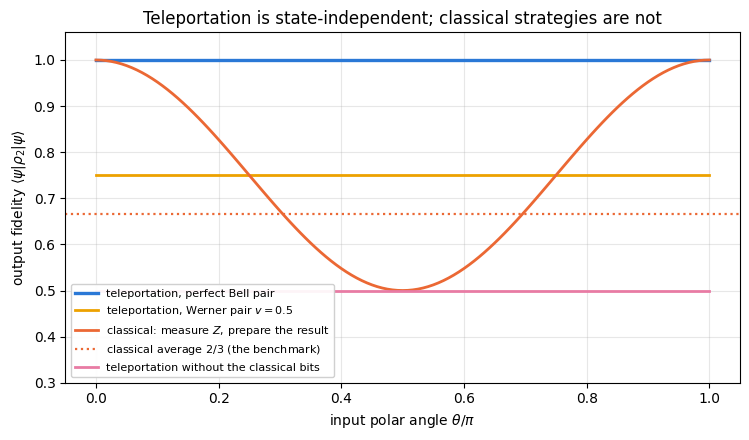

In [12]:
# ==============================================================================
# FIGURE: teleportation vs the best classical strategy, as a function of the input state
# ==============================================================================
th_grid = np.linspace(0.0, np.pi, 121)
F_tele_ideal, F_tele_w, F_nocorr_curve = [], [], []
res_half = werner_resource(0.5)
for th in th_grid:
    ket = qubit_state(float(th))
    rho_in = jnp.outer(ket, jnp.conj(ket))
    F_tele_ideal.append(float(fid_state_dm(ket, teleport_channel_dm(rho_in, rho_bell))))
    F_tele_w.append(float(fid_state_dm(ket, teleport_channel_dm(rho_in, res_half))))
    F_nocorr_curve.append(0.25 * sum(float(jnp.abs(jnp.vdot(ket, P @ ket)) ** 2) for P in (I2, X, Y, Z)))
F_class_z = np.cos(th_grid / 2) ** 4 + np.sin(th_grid / 2) ** 4     # measure Z, prepare the eigenstate

fig, ax = plt.subplots(figsize=(7.6, 4.5))
ax.plot(th_grid / np.pi, F_tele_ideal, "-", color=PALETTE[0], lw=2.4, label="teleportation, perfect Bell pair")
ax.plot(th_grid / np.pi, F_tele_w, "-", color=PALETTE[3], lw=2, label=r"teleportation, Werner pair $v=0.5$")
ax.plot(th_grid / np.pi, F_class_z, "-", color=PALETTE[1], lw=2, label="classical: measure $Z$, prepare the result")
ax.axhline(2 / 3, color=PALETTE[1], ls=":", lw=1.6, label=r"classical average $2/3$ (the benchmark)")
ax.plot(th_grid / np.pi, F_nocorr_curve, "-", color=PALETTE[4], lw=2,
        label="teleportation without the classical bits")
ax.set_xlabel(r"input polar angle $\theta/\pi$")
ax.set_ylabel(r"output fidelity $\langle\psi|\rho_2|\psi\rangle$")
ax.set_ylim(0.3, 1.06)
ax.set_title("Teleportation is state-independent; classical strategies are not")
ax.legend(fontsize=8, loc="lower left", frameon=True, framealpha=0.92)
fig.tight_layout()
plt.show()

The figure contrasts the two kinds of strategy. The classical "measure $Z$, prepare what you
saw" curve is $1$ at the poles — where the input *is* a classical bit — and $1/2$ at the equator, averaging to exactly $2/3$; it
buys its score by being good on a favoured subset of inputs. Teleportation is a flat line: perfect for every input with a perfect
resource, and still flat (at $(1+v)/2=0.75$) with a Werner pair of visibility $0.5$, because white noise is isotropic. Without the
classical bits the fidelity is the flat $1/2$ of Eq. (6). "Beating $2/3$" therefore means something stronger than it sounds:
beating it *uniformly*, without a preferred axis.

## 11. The same computation with quantum trajectories

The density tensor of $N$ qubits needs $4^N$ numbers; a pure state needs $2^N$. The trajectory (Monte-Carlo wave function)
unravelling trades that memory for statistics: apply each Kraus operator *stochastically* with probability
$\lVert K_m\vert\psi\rangle\rVert^2$, follow the pure state, and average observables over $M$ trajectories. The average converges to
the density-matrix answer with an error $\propto1/\sqrt M$.

Here the protocol contains a *second* source of randomness — Alice's measurement — and the same machinery handles both: one PRNG
key per trajectory, split into a noise key and two measurement keys. The entire run is a pure function of its key, so `vmap` over
keys gives $M$ independent trajectories in one compiled call.

A useful dictionary: depolarising noise of strength $p$ on one half of $\vert\Phi^+\rangle$ produces exactly a Werner state with
visibility $v=1-\tfrac{4p}{3}$ and singlet fraction $F=1-p$, hence

$$\bar F=\frac{2(1-p)+1}{3}=1-\frac{2p}{3} , \tag{15}$$

a straight line from 1 at $p=0$ to $2/3$ at $p=1/2$ — the classical threshold is reached exactly when the Werner visibility hits
$1/3$, i.e. when the pair stops being entangled.

In [13]:
# ==============================================================================
# STEP 8: trajectory (MCWF) version of noisy teleportation
# ==============================================================================
@partial(jax.jit, static_argnums=(3,))
def teleport_traj_batch(key, ket, p, shots):
    """`shots` trajectories of the protocol with depolarising noise of strength p on Bob's resource qubit.

    JAX   one key per trajectory; inside, the key is split into (noise, measurement 1, measurement 2).
          `apply_kraus_mcwf` picks a Kraus branch with probability ||K_m psi||^2 -- a categorical draw on a
          4-element probability vector, no Python branching.
    """
    K = kraus_depolarizing(p)

    def one(k):
        k_noise, k_rest = jax.random.split(k)
        psi = three_qubit_input(ket)
        psi = apply_kraus_mcwf(k_noise, psi, K, [2])               # noise on Bob's half of the pair
        psi = alice_bell_measurement_gates(psi)
        k1, k2 = jax.random.split(k_rest)
        m1, psi = measure_z(k1, psi, 0)
        m2, psi = measure_z(k2, psi, 1)
        psi = apply_gate(psi, jnp.where(m2 == 1, X, I2), [2])
        psi = apply_gate(psi, jnp.where(m1 == 1, Z, I2), [2])
        return fid_state_dm(ket, rdm(psi, [2]))

    return jax.vmap(one)(jax.random.split(key, shots))


def avg_fidelity_traj(key, p, shots):
    """Average teleportation fidelity over the 6-state design AND over trajectories.  Returns (mean, SE)."""
    keys = jax.random.split(key, len(SIX_STATES))
    vals = jnp.stack([teleport_traj_batch(k, v, p, shots) for k, v in zip(keys, SIX_STATES)])
    return float(jnp.mean(vals)), float(jnp.std(vals) / np.sqrt(vals.size))


# PARAMETERS ---------------------------------------------------------------------------------------
P_GRID = np.linspace(0.0, 0.75, 16)      # depolarising strength on Bob's resource qubit
TRAJ_PER_STATE = 2000                    # trajectories per input state (6 states -> 12000 runs per point)
# --------------------------------------------------------------------------------------------------
t0 = time.perf_counter()
F_dm, F_tr, SE_tr, Fres_p, neg_p = [], [], [], [], []
for i, p in enumerate(P_GRID):
    res = noisy_resource(float(p), kraus_depolarizing)
    F_dm.append(avg_fidelity_channel(lambda r, R=res: teleport_channel_dm(r, R)))
    m, se = avg_fidelity_traj(jax.random.PRNGKey(700 + i), float(p), TRAJ_PER_STATE)
    F_tr.append(m); SE_tr.append(se)
    Fres_p.append(singlet_fraction(res))
    neg_p.append(float(negativity(res, [0])[0]))
F_dm, F_tr, SE_tr = np.array(F_dm), np.array(F_tr), np.array(SE_tr)
print(f"({len(P_GRID)} noise values x 6 input states x {TRAJ_PER_STATE} trajectories "
      f"= {len(P_GRID) * 6 * TRAJ_PER_STATE} protocol runs in {time.perf_counter() - t0:.1f} s)\n")
# "pull" = deviation in units of the reported standard error.  At p = 0 the protocol is deterministic, every
# trajectory returns F = 1 and the sample standard deviation is pure round-off: the pull is then meaningless,
# so we mark those points instead of dividing by (almost) zero.
NOISY = SE_tr > 1e-9                                  # points where the sample spread is a real statistical spread
pulls = np.where(NOISY, (F_tr - F_dm) / np.where(NOISY, SE_tr, 1.0), 0.0)
print(f"{'p':>6s} {'F_res':>8s} {'F_avg (DM)':>11s} {'F_avg (traj)':>13s} {'SE':>8s} "
      f"{'1 - 2p/3':>9s} {'pull':>6s} {'negativity':>11s}")
for p, fr, fd, ft, se, pl, ng in zip(P_GRID, Fres_p, F_dm, F_tr, SE_tr, pulls, neg_p):
    print(f"{p:6.3f} {fr:8.5f} {fd:11.6f} {ft:13.6f} {se:8.5f} {1 - 2 * p / 3:9.6f} "
          f"{pl:+6.2f} {ng:11.6f}")
print(f"\nCHECKPOINT  max|F_avg(DM) - (1 - 2p/3)| = {np.max(np.abs(F_dm - (1 - 2 * P_GRID / 3))):.2e}")
print(f"            max|F_avg(traj) - F_avg(DM)| = {np.max(np.abs(F_tr - F_dm)):.4f}  "
      f"(typical SE = {SE_tr[NOISY].mean():.4f}, largest |pull| = {np.max(np.abs(pulls)):.2f} sigma,"
      f" RMS pull = {np.sqrt(np.mean(pulls[NOISY] ** 2)):.2f}; the p = 0 point is deterministic and excluded)")
assert np.max(np.abs(F_dm - (1 - 2 * P_GRID / 3))) < 1e3 * TOL
assert np.max(np.abs(pulls)) < 5.0

(16 noise values x 6 input states x 2000 trajectories = 192000 protocol runs in 2.5 s)

     p    F_res  F_avg (DM)  F_avg (traj)       SE  1 - 2p/3   pull  negativity
 0.000  1.00000    1.000000      1.000000  0.00000  1.000000  +0.00    0.500000
 0.050  0.95000    0.966667      0.966750  0.00164  0.966667  +0.05    0.450000
 0.100  0.90000    0.933333      0.936833  0.00222  0.933333  +1.58    0.400000
 0.150  0.85000    0.900000      0.895750  0.00279  0.900000  -1.52    0.350000
 0.200  0.80000    0.866667      0.865833  0.00311  0.866667  -0.27    0.300000
 0.250  0.75000    0.833333      0.830833  0.00342  0.833333  -0.73    0.250000
 0.300  0.70000    0.800000      0.798833  0.00366  0.800000  -0.32    0.200000
 0.350  0.65000    0.766667      0.766500  0.00386  0.766667  -0.04    0.150000
 0.400  0.60000    0.733333      0.733083  0.00404  0.733333  -0.06    0.100000
 0.450  0.55000    0.700000      0.698667  0.00419  0.700000  -0.32    0.050000
 0.500  0.50000    0.666667     

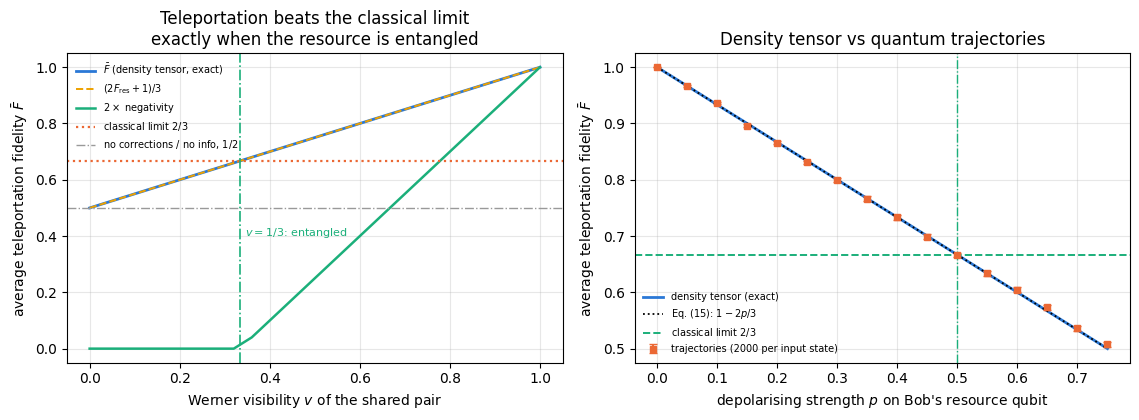

In [14]:
# ==============================================================================
# FIGURE: teleportation fidelity vs resource quality -- exact, trajectories, thresholds
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

vv = np.array([r[0] for r in rows_w])
axes[0].plot(vv, [r[2] for r in rows_w], "-", color=PALETTE[0], lw=2, label=r"$\bar F$ (density tensor, exact)")
axes[0].plot(vv, [(2 * r[1] + 1) / 3 for r in rows_w], "--", color=PALETTE[3], lw=1.4,
             label=r"$(2F_{\rm res}+1)/3$")
axes[0].plot(vv, [r[4] * 2 for r in rows_w], "-", color=PALETTE[2], lw=1.8, label=r"$2\times$ negativity")
axes[0].axhline(2 / 3, color=PALETTE[1], ls=":", lw=1.6, label=r"classical limit $2/3$")
axes[0].axhline(0.5, color="0.6", ls="-.", lw=1.0, label=r"no corrections / no info, $1/2$")
axes[0].axvline(1 / 3, color=PALETTE[2], ls="-.", lw=1.2)
axes[0].text(0.345, 0.40, r"$v=1/3$: entangled", fontsize=8, color=PALETTE[2])
axes[0].set_xlabel("Werner visibility $v$ of the shared pair")
axes[0].set_ylabel(r"average teleportation fidelity $\bar F$")
axes[0].set_title("Teleportation beats the classical limit\nexactly when the resource is entangled")
axes[0].legend(fontsize=7, loc="upper left")

axes[1].plot(P_GRID, F_dm, "-", color=PALETTE[0], lw=2, label="density tensor (exact)")
axes[1].errorbar(P_GRID, F_tr, yerr=SE_tr, fmt=MARKERS[1], color=PALETTE[1], ms=5, capsize=3,
                 label=f"trajectories ({TRAJ_PER_STATE} per input state)")
axes[1].plot(P_GRID, 1 - 2 * P_GRID / 3, "k:", lw=1.3, label=r"Eq. (15): $1-2p/3$")
axes[1].axhline(2 / 3, color=PALETTE[2], ls="--", lw=1.4, label=r"classical limit $2/3$")
axes[1].axvline(0.5, color=PALETTE[2], ls="-.", lw=1.0)
axes[1].set_xlabel("depolarising strength $p$ on Bob's resource qubit")
axes[1].set_ylabel(r"average teleportation fidelity $\bar F$")
axes[1].set_title("Density tensor vs quantum trajectories")
axes[1].legend(fontsize=7, loc="lower left")
fig.tight_layout()
plt.show()

Left panel: the exact average fidelity of the Werner family is the straight line $(1+v)/2$,
it crosses the classical $2/3$ at $v=1/3$, and the negativity (green) leaves zero at exactly the same point. Teleportation is thus
a *faithful* witness of entanglement for this family, unlike CHSH, whose threshold sits far to the right at $v=1/\sqrt2$.
At $v=0$ the fidelity is $1/2$: with no entanglement the protocol degenerates into handing Bob the maximally mixed state.

Right panel: the trajectory estimates sit on the exact curve at every noise strength, with pulls of order one standard error, which
is exactly what two correct implementations of the same physics must do. The straight line $1-2p/3$ of Eq. (15) hits $2/3$ at
$p=1/2$, where the Werner visibility $1-\tfrac43p$ equals $1/3$ and the pair stops being entangled.

## 12. How many trajectories? The $1/\sqrt{M}$ law and the cost of each method

The two methods answer the same question with different resources. The density tensor is exact but stores $4^N$ numbers; the
trajectories store $2^N$ but need $M$ of them, and their error falls only as $1/\sqrt M$: to gain one digit you need 100 times more
work. For the three qubits here the density tensor wins easily ($64$ versus $8$ complex numbers is no obstacle), but the crossover
arrives quickly: at $N=14$ the density tensor needs $4^{14}=2^{28}\approx2.7\cdot10^8$ complex numbers ($4.3$ GB in double
precision) while a trajectory needs $2^{14}$ complex numbers, i.e. $0.26$ MB. We measure both the convergence and the cost.

In [15]:
# ==============================================================================
# BENCHMARK: convergence of the trajectory estimate and cost of the two methods
# ==============================================================================
P_BENCH = 0.30
res_bench = noisy_resource(P_BENCH, kraus_depolarizing)
F_exact_bench = avg_fidelity_channel(lambda r: teleport_channel_dm(r, res_bench))

M_GRID = [50, 200, 800, 3200, 12800]
print(f"depolarising p = {P_BENCH}:  exact F_avg = {F_exact_bench:.6f}\n")
print(f"{'M per state':>12s} {'mean F_avg':>11s} {'RMS error':>10s} {'mean SE':>9s} {'RMS error * sqrt(M)':>20s}")
N_REP = 12            # independent repetitions per M: a SINGLE estimate is far too noisy to reveal a 1/sqrt(M) law
errs = []
for j, M in enumerate(M_GRID):
    est = [avg_fidelity_traj(jax.random.PRNGKey(2000 + 100 * j + r), P_BENCH, M) for r in range(N_REP)]
    means = np.array([e[0] for e in est])
    rms = float(np.sqrt(np.mean((means - F_exact_bench) ** 2)))
    errs.append(rms)
    print(f"{M:12d} {means.mean():11.6f} {rms:10.5f} {np.mean([e[1] for e in est]):9.5f} {rms * np.sqrt(M):20.4f}")

# timing: one exact channel evaluation vs one batch of trajectories
f_dm = jax.jit(lambda R: teleport_channel_dm(jnp.outer(SIX_STATES[2], jnp.conj(SIX_STATES[2])), R))
f_dm(res_bench).block_until_ready()
t0 = time.perf_counter()
for _ in range(20):
    f_dm(res_bench).block_until_ready()
t_dm = (time.perf_counter() - t0) / 20

teleport_traj_batch(jax.random.PRNGKey(0), SIX_STATES[2], P_BENCH, 12800).block_until_ready()
t0 = time.perf_counter()
for _ in range(3):
    teleport_traj_batch(jax.random.PRNGKey(1), SIX_STATES[2], P_BENCH, 12800).block_until_ready()
t_tr = (time.perf_counter() - t0) / 3

print(f"\n  one exact channel evaluation (rank-6 density tensor) : {t_dm * 1e3:8.3f} ms")
print(f"  12800 trajectories for one input state               : {t_tr * 1e3:8.3f} ms "
      f"({t_tr / 12800 * 1e6:.2f} us per trajectory)")
print(f"  memory: density tensor of N qubits = 4^N complex numbers; one trajectory = 2^N")
for N in (3, 8, 14, 20):
    print(f"     N = {N:2d}:  density tensor {16 * 4 ** N / 1e6:12.3f} MB   one trajectory "
          f"{16 * 2 ** N / 1e6:10.6f} MB")

depolarising p = 0.3:  exact F_avg = 0.800000

 M per state  mean F_avg  RMS error   mean SE  RMS error * sqrt(M)


          50    0.793611    0.02761   0.02329               0.1952


         200    0.802361    0.01116   0.01149               0.1579


         800    0.799878    0.00683   0.00577               0.1933


        3200    0.799605    0.00307   0.00289               0.1735


       12800    0.799830    0.00148   0.00144               0.1677



  one exact channel evaluation (rank-6 density tensor) :    0.076 ms
  12800 trajectories for one input state               :   33.278 ms (2.60 us per trajectory)
  memory: density tensor of N qubits = 4^N complex numbers; one trajectory = 2^N
     N =  3:  density tensor        0.001 MB   one trajectory   0.000128 MB
     N =  8:  density tensor        1.049 MB   one trajectory   0.004096 MB
     N = 14:  density tensor     4294.967 MB   one trajectory   0.262144 MB
     N = 20:  density tensor 17592186.044 MB   one trajectory  16.777216 MB


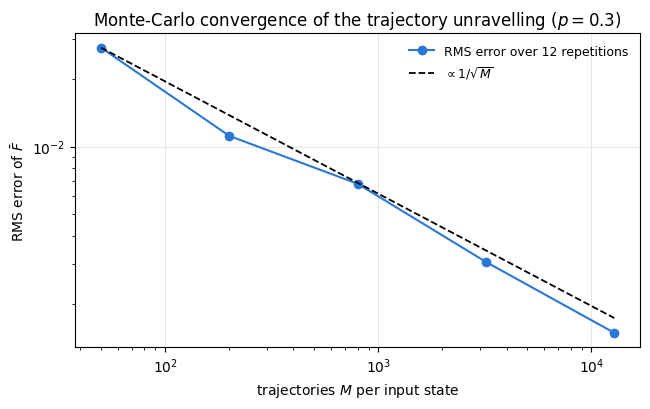

In [16]:
# ==============================================================================
# FIGURE: trajectory error vs number of trajectories
# ==============================================================================
fig, ax = plt.subplots(figsize=(6.6, 4.2))
Ms = np.array(M_GRID, dtype=float)
ax.loglog(Ms, errs, MARKERS[0] + "-", color=PALETTE[0], ms=6,
          label=r"RMS error over %d repetitions" % N_REP)
ax.loglog(Ms, errs[0] * np.sqrt(Ms[0] / Ms), "k--", lw=1.3, label=r"$\propto 1/\sqrt{M}$")
ax.set_xlabel("trajectories $M$ per input state")
ax.set_ylabel(r"RMS error of $\bar F$")
ax.set_title(f"Monte-Carlo convergence of the trajectory unravelling ($p={P_BENCH}$)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

The root-mean-square error over independent repetitions follows the $1/\sqrt M$ law — the
product $\text{RMS}\times\sqrt M$ is constant to within the scatter one expects from 12 repetitions — and it agrees with the
standard error each run reports from its own data. (A *single* estimate would have been useless for this plot: at these sample
sizes one realisation can land anywhere within a couple of standard errors, so the apparent "error" would jump around by a factor
of ten. Averaging over repetitions is how one measures a convergence rate.) At three qubits the exact density-tensor evaluation is
far cheaper than any useful number of trajectories, but the memory table shows why that reverses: the density tensor grows as
$4^N$, so by $N\approx14$ it needs gigabytes while a trajectory is still a fraction of a megabyte. The rule of thumb is:
**density tensor for
$N\lesssim7$, trajectories beyond**, and always validate the trajectory code against the density tensor on a small system first —
which is exactly what we just did.

## 13. Deferred measurement: the same protocol without any measurement

There is a purely unitary version of teleportation, and comparing the two teaches a general principle.

**Principle of deferred measurement.** A measurement followed by a classically controlled gate can always be replaced by a
*quantum*-controlled gate followed (if desired) by the measurement. Concretely: "measure qubit $c$, and apply $U$ to qubit $t$ if
the result was 1" acts on the rest of the system exactly like "apply controlled-$U$ with control $c$ and target $t$, then measure
$c$".

*Why.* Write the state as $\vert0\rangle_c\vert\chi_0\rangle+\vert1\rangle_c\vert\chi_1\rangle$. The measure-and-correct route
yields $\vert0\rangle\vert\chi_0\rangle$ with probability $\lVert\chi_0\rVert^2$ and $\vert1\rangle U\vert\chi_1\rangle$ with
probability $\lVert\chi_1\rVert^2$. The controlled gate yields $\vert0\rangle\vert\chi_0\rangle+\vert1\rangle U\vert\chi_1\rangle$,
which upon measuring $c$ gives the same two branches with the same probabilities. Since nothing later touches $c$, the two
procedures are indistinguishable. $\square$

Applied to teleportation: replace "if $m_2=1$ apply $X_2$" by $\text{CNOT}_{1\to2}$ and "if $m_1=1$ apply $Z_2$" by
$\text{CZ}_{0,2}$. Starting from Eq. (3) and using $\text{CNOT}_{1\to2}$ to cancel $X^{m_2}$ and $\text{CZ}_{0,2}$ to cancel
$Z^{m_1}$,

$$\frac12\sum_{m_1m_2}\vert m_1m_2\rangle\otimes X^{m_2}Z^{m_1}\vert\psi\rangle
\;\xrightarrow{\ \text{CNOT}_{1\to2},\ \text{CZ}_{0,2}\ }\;
\left(\frac12\sum_{m_1m_2}\vert m_1m_2\rangle\right)\otimes\vert\psi\rangle
=\vert+\rangle_0\vert+\rangle_1\otimes\vert\psi\rangle_2 . \tag{16}$$

The final state is a **product**, completely deterministic, with Alice's qubits in $\vert+\rangle\vert+\rangle$ — carrying, as they
must, no trace of $\vert\psi\rangle$. This is the form in which teleportation appears inside larger circuits (measurement-based
computing, gate teleportation), because it needs no classical wire at all; the price is that Bob's qubit must stay coherent and in
the same device as Alice's.

In [17]:
# ==============================================================================
# STEP 9: the deferred-measurement (all-unitary) version
# ==============================================================================
@jax.jit
def teleport_deferred(ket):
    """Teleportation with the measurement and feed-forward replaced by two controlled gates.
    CNOT(1 -> 2) replaces 'if m2: X_2';  CZ(0, 2) replaces 'if m1: Z_2'.  Returns the 3-qubit state."""
    psi = alice_bell_measurement_gates(three_qubit_input(ket))
    psi = apply_gate(psi, CNOT, [1, 2])                # quantum-controlled X  (control = Alice's qubit 1)
    return apply_gate(psi, CZ, [0, 2])                 # quantum-controlled Z  (control = Alice's qubit 0)


plus = product_state("+")
print(f"{'input':28s} {'max|psi_out - |++>(x)|psi>|':>28s} {'F(Bob, exact)':>15s} "
      f"{'purity(rho_2)':>14s} {'F vs measured version':>22s}")
for i, (name, (th, ph)) in enumerate(TEST_INPUTS.items()):
    ket = qubit_state(th, ph)
    psi_def = teleport_deferred(ket)
    target = jnp.einsum("a,b,c->abc", plus, plus, ket)
    rho2 = rdm(psi_def, [2])
    _, _, psi_meas = teleport(jax.random.PRNGKey(77 + i), ket)      # the measured version, one random run
    F_cross = float(fidelity_dm(rho2, rdm(psi_meas, [2])))
    print(f"{name:28s} {max_abs(psi_def - target):28.2e} {float(fid_state_dm(ket, rho2)):15.12f} "
          f"{float(purity(rho2)):14.10f} {F_cross:22.12f}")
    assert max_abs(psi_def - target) < 1e3 * TOL

print("\nCHECKPOINT  the deferred-measurement circuit produces exactly |+>|+> (x) |psi>: Bob's qubit is pure,")
print("            carries the input with fidelity 1, and agrees with the measured version in every branch.")
print("\nOutcome statistics of the deferred circuit (measuring qubits 0,1 AFTERWARDS):")
probs = np.abs(np.asarray(teleport_deferred(qubit_state(np.pi / 3, 0.7))).reshape(4, 2)) ** 2
print("   p(m1,m2) = " + "  ".join(f"{lab}: {v:.4f}" for lab, v in zip(("00", "01", "10", "11"), probs.sum(axis=1))))

input                         max|psi_out - |++>(x)|psi>|   F(Bob, exact)  purity(rho_2)  F vs measured version


|0>                                              0.00e+00  1.000000000000   1.0000000000         1.000000000000
|1>                                              0.00e+00  1.000000000000   1.0000000000         1.000000000000
|+>                                              0.00e+00  1.000000000000   1.0000000000         1.000000000000
Ry(pi/4)|0>                                      0.00e+00  1.000000000000   1.0000000000         1.000000000000
Ry(3pi/4)|0>                                     2.78e-17  1.000000000000   1.0000000000         1.000000000000
generic (th=pi/3, ph=0.7)                        0.00e+00  1.000000000000   1.0000000000         1.000000000000

CHECKPOINT  the deferred-measurement circuit produces exactly |+>|+> (x) |psi>: Bob's qubit is pure,
            carries the input with fidelity 1, and agrees with the measured version in every branch.

Outcome statistics of the deferred circuit (measuring qubits 0,1 AFTERWARDS):
   p(m1,m2) = 00: 0.2500  01: 0.2500  10: 0.25

The deferred circuit gives *exactly* $\vert+\rangle\vert+\rangle\otimes\vert\psi\rangle$ for every input, so Bob's qubit is pure
(purity 1) with fidelity 1 — and it is identical, branch by branch, to the state produced by the measured protocol. Measuring
Alice's qubits afterwards still yields the four uniform outcomes, confirming the principle of deferred measurement: postponing the
measurement changes nothing that can be observed.

## 14. Key takeaways

* **No-cloning is linearity.** A unitary that copies $\vert0\rangle$ and $\vert1\rangle$ maps $\alpha\vert0\rangle+\beta\vert1\rangle$
  to the *entangled* state $\alpha\vert00\rangle+\beta\vert11\rangle$, never to $\vert\psi\rangle\vert\psi\rangle$. Equivalently,
  unitaries preserve overlaps while cloning would square them, so only mutually orthogonal states can be copied. The CNOT "copier"
  achieves fidelity 1 at the poles of the Bloch sphere, exactly $1/2$ at the equator and $2/3$ on average, against the $5/6$ of the
  optimal universal cloner. Neither an ancilla nor a non-unitary linear machine helps.
* **Teleportation is one algebraic identity.** Expanding $\vert\psi\rangle_0\vert\Phi^+\rangle_{12}$ in the Bell basis of qubits
  $(0,1)$ gives $\tfrac12\sum_{m_1m_2}\vert B_{m_1m_2}\rangle\otimes X^{m_2}Z^{m_1}\vert\psi\rangle$. Four equal amplitudes, four
  Pauli corrections, two classical bits.
* **Nothing is sent faster than light.** All four outcomes have probability $1/4$ for every input, and Bob's pre-correction state is
  the Pauli twirl $\tfrac14\sum_PP\rho P=\mathbb 1/2$ — verified to machine precision for every test state. Skipping the corrections
  gives fidelity exactly $1/2$, for *each* input, not just on average.
* **The classical benchmark is $2/3$**, derived from $\int d\psi(\vert\psi\rangle\langle\psi\vert)^{\otimes2}=P_{\rm sym}/3$; it is
  achieved by *any* rank-one POVM that prepares the state it measured (projective or not — the SIC-POVM scores $2/3$ too), while a
  wrong preparation rule does worse. Beating $2/3$ certifies that something non-classical was used.
* **A noisy resource gives $\bar F=(2F_{\rm res}+1)/3$**, hence $\bar F=(1+v)/2$ for Werner states. The classical threshold
  $\bar F>2/3$ coincides *exactly* with the entanglement threshold $v>1/3$ — so teleportation witnesses entanglement where CHSH
  ($v>1/\sqrt2$) cannot. The formula is easiest to derive for Bell-diagonal resources (a Pauli channel), but the numerics showed it
  holds for amplitude-damped and even Haar-random resources, because the deeper statement is $\bar F=(2F_e+1)/3$ with $F_e$ the
  **entanglement fidelity** of the induced channel — and the standard protocol always has $F_e$ equal to the resource's singlet
  fraction. Optimality is what fails for a non-Bell-diagonal resource: local pre-processing can then raise the singlet fraction.
* **Two unravellings, one physics.** The exact density-tensor channel and the trajectory simulation agree within one standard error
  at every noise strength, with the trajectory error following $1/\sqrt M$; the density tensor costs $4^N$ memory, a trajectory
  $2^N$.
* **Deferred measurement**: replacing the measurement and feed-forward by CNOT and CZ produces the deterministic product state
  $\vert+\rangle\vert+\rangle\otimes\vert\psi\rangle$ — the same physics with no classical wire.
* **Implementation**: mid-circuit measurement is `apply_gate` with a projector plus a renormalisation, feed-forward is `jnp.where`
  on a traced outcome, and the resulting protocol is a single pure function of a PRNG key — hence jittable, vmappable over shots,
  inputs and trajectories, and reproducible.

## 15. Exercises

1. ★ **Other resources.** Run the protocol with $\vert\Psi^-\rangle$ instead of $\vert\Phi^+\rangle$ as the shared pair. Which
   corrections does Bob need now? Derive the new table from Eq. (2) and verify it with `teleport_channel_dm` by replacing the
   correction operators.
2. ★ **Where did the state go?** For the input $\vert+\rangle$, print the reduced density matrices of all three qubits *after* the
   protocol. Show that qubits 0 and 1 are in definite computational basis states (the measurement outcomes) and carry no trace of
   the input — as no-cloning demands.
3. ★★ **Entanglement swapping (extend the code).** Replace Alice's input qubit by half of a *second* Bell pair (4 qubits total) and
   run the same Bell measurement on the two inner qubits. Show that the two outer qubits, which have never interacted, end up in a
   Bell state, and compute their negativity for each outcome. This is the building block of a quantum repeater.
4. ★★ **Teleporting half of an entangled pair (physics).** Teleport one qubit of a Bell pair and verify that the entanglement is
   preserved: compute the negativity between the untouched qubit and Bob's output. Then repeat with a Werner resource of visibility
   $v$ and find the $v$ at which the output stops being entangled. Is it the same as the $\bar F=2/3$ threshold?
5. ★★ **Noise on the gates, not the resource (extend the code).** Add depolarising noise of strength $p$ after every gate of the
   protocol (both Alice's and Bob's) and plot $\bar F(p)$ against the resource-noise curve of Section 11. Which is more damaging at
   equal $p$, and why?
6. ★★ **Imperfect corrections (physics).** Suppose Bob's classical channel flips each bit with probability $q$. Derive the
   resulting channel (a Pauli channel again) and its average fidelity $\bar F(q)$, and verify numerically. At which $q$ does the
   protocol fall below $2/3$?
7. ★★★ **Verifying teleportation like an experimentalist.** Instead of computing $\langle\psi\vert\rho_2\vert\psi\rangle$
   directly, *estimate* it from measurements: reconstruct Bob's qubit with the single-qubit tomography of
   [23 — quantum state tomography](../ch08_quantum_information_protocols/23_quantum_state_tomography.ipynb) using $M$ shots per
   Pauli setting, and plot the reconstructed fidelity with bootstrap error bars versus $M$. How many shots are needed to claim
   $\bar F>2/3$ at $5\sigma$ with a Werner resource of $v=0.5$?
8. ★★★ **Gate teleportation.** Modify the deferred-measurement circuit so that Bob receives $U\vert\psi\rangle$ instead of
   $\vert\psi\rangle$, for a $U$ of your choice, *without* applying $U$ to Bob's qubit at the end — by preparing the resource in the
   state $(\mathbb 1\otimes U)\vert\Phi^+\rangle$ instead. Verify it numerically, and explain why this trick (applying an expensive
   gate offline, before the data arrives) is the basis of magic-state injection in fault-tolerant quantum computing.

## References

* C. H. Bennett, G. Brassard, C. Crépeau, R. Jozsa, A. Peres and W. K. Wootters, *Teleporting an unknown quantum state via dual
  classical and Einstein-Podolsky-Rosen channels*, Phys. Rev. Lett. **70**, 1895 (1993) — the protocol.
* W. K. Wootters and W. H. Zurek, *A single quantum cannot be cloned*, Nature **299**, 802 (1982) — the no-cloning theorem.
* V. Bužek and M. Hillery, *Quantum copying: beyond the no-cloning theorem*, Phys. Rev. A **54**, 1844 (1996) — the universal
  $1\to2$ cloning machine with single-copy fidelity $5/6$; its optimality was proved by N. Gisin and S. Massar, *Optimal quantum
  cloning machines*, Phys. Rev. Lett. **79**, 2153 (1997), and by D. Bruß, D. P. DiVincenzo, A. Ekert, C. A. Fuchs, C. Macchiavello
  and J. A. Smolin, *Optimal universal and state-dependent quantum cloning*, Phys. Rev. A **57**, 2368 (1998).
* S. Massar and S. Popescu, *Optimal extraction of information from finite quantum ensembles*, Phys. Rev. Lett. **74**, 1259 (1995)
  — the $2/3$ classical benchmark as the $N=1$ case of $(N+1)/(N+2)$.
* M. Horodecki, P. Horodecki and R. Horodecki, *General teleportation channel, singlet fraction, and quasidistillation*,
  Phys. Rev. A **60**, 1888 (1999) — the relation $\bar F=(2f+1)/3$ between the singlet fraction and the teleportation fidelity.
* M. A. Nielsen, *A simple formula for the average gate fidelity of a quantum dynamical operation*, Phys. Lett. A **303**, 249
  (2002) — the relation $\bar F=(dF_e+1)/(d+1)$ between average fidelity and entanglement fidelity.
* R. F. Werner, *Quantum states with Einstein-Podolsky-Rosen correlations admitting a hidden-variable model*,
  Phys. Rev. A **40**, 4277 (1989) — Werner states.
* D. Bouwmeester, J.-W. Pan, K. Mattle, M. Eibl, H. Weinfurter and A. Zeilinger, *Experimental quantum teleportation*,
  Nature **390**, 575 (1997) — the first photonic demonstration.
* J.-G. Ren et al., *Ground-to-satellite quantum teleportation*, Nature **549**, 70 (2017) — teleportation over 1400 km to the
  Micius satellite.
* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000), Sections 1.3.5,
  1.3.7 and 4.4 — no-cloning, teleportation, and the principle of deferred measurement.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/